# Project: Can AI predict severe road accidents?

Every year, thousands of road accidents occur in the United States, causing injuries, property damage, and fatalities. Understanding what factors contribute to the severity of these accidents can help policymakers, city planners, and drivers make safer decisions. In this project, we investigate which conditions are most predictive of high-severity accidents and build models to predict whether a given accident is likely to be severe.

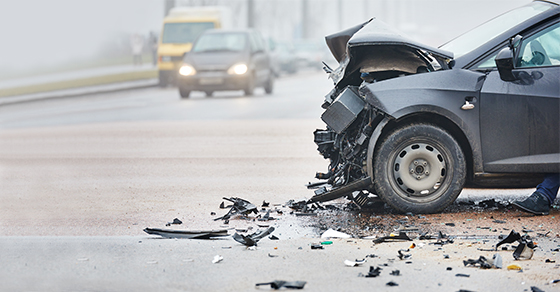

#### The Dataset - `accidents_dat`

**Description**
This is a countrywide car accident dataset that covers 49 states of the USA. The accident data were collected from February 2016 to March 2023, using multiple APIs that provide streaming traffic incident (or event) data. These APIs broadcast traffic data captured by various entities, including the US and state departments of transportation, law enforcement agencies, traffic cameras, and traffic sensors within the road networks. The full dataset currently contains approximately 7.7 million accident records, but we have used a sample of 500,000 for this project (our biggest dataset yet!!)

For this project, we will also convert the original Severity variable into a binary target:

High_Severity:

0 = Low/Medium severity (original Severity 1 & 2)

1 = High severity (original Severity 3 & 4)

**Variables**
- `ID`: Unique identifier for each accident
- `Start_Time`: Timestamp when the accident started
- `End_Time`: Timestamp when the accident ended
- `Start_Lat`: Latitude of the accident start location
- `Start_Lng`: Longitude of the accident start location
- `State`: US state where the accident occurred
- `City`: City where the accident occurred
- `Zipcode`: Zip code of the accident
- `Temperature(F)`: Temperature at the time of the accident
- `Wind_Chill(F)`: Wind chill at the time of the accident
- `Humidity(%)`: Humidity at the time of the accident
- `Pressure(in)`: Atmospheric pressure
- `Visibility(mi)`: Visibility in miles
- `Distance (mi)`: Length of street in miles
- `Wind_Speed(mph)`: Wind speed
- `Precipitation(in)`: Precipitation
- `Weather_Condition`: Description of weather conditions
- `Amenity`: Whether the accident happened near an amenity
- `Bump`: Whether the accident happened near a bump
- `Crossing`: Whether the accident happened near a crossing
- `Junction`: Whether the accident happened at a junction
- `Traffic_Signal`: Whether the accident happened near a traffic signal
- `Sunrise_Sunset`: Day or Night
- `High_Severity`: Target variable (0 = Low/Medium, 1 = High)

**Data Source**

All the data for this project was gathered <a href = "https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents">here on Kaggle </a>

- Moosavi, Sobhan, Mohammad Hossein Samavatian, Srinivasan Parthasarathy, and Rajiv Ramnath. “A Countrywide Traffic Accident Dataset.”, 2019.

- Moosavi, Sobhan, Mohammad Hossein Samavatian, Srinivasan Parthasarathy, Radu Teodorescu, and Rajiv Ramnath. "Accident Risk Prediction based on Heterogeneous Sparse Data: New Dataset and Insights." In proceedings of the 27th ACM SIGSPATIAL International Conference on Advances in Geographic Information Systems, ACM, 2019.

#### Getting set up
First, let's download our packages and dataset

In [1]:
# Download the pandas and numpy libraries, which contain helpful Python commands
import pandas as pd
import numpy as np

# Download the seaborn library, which contains useful data visualization tools
import seaborn as sns

# Download the motplotlib.pyplot library, which is a powerful plotting library
import matplotlib.pyplot as plt

# Download the statsmodels.formula.api library, which allows for estimating and interpreting statistical models
import statsmodels.formula.api as smf

pd.set_option('display.max_columns', None)   # show all columns

In [2]:
# Path is relative to the notebook; the dataset lives in ./data/
# This file (~3GB, 7.7M rows) is the full US Accidents dataset (Feb 2016 - Mar 2023).
accidents_full = pd.read_csv('data/US_Accidents_March23.csv')
print('Full dataset shape:', accidents_full.shape)

# Working with 7.7M rows is slow and memory-heavy, and we don't need it all
# for a teaching project. We take a reproducible random sample of 200,000 rows.
# random_state=42 means anyone who runs this notebook gets the SAME sample.
accidents_dat = accidents_full.sample(200_000, random_state=42).reset_index(drop=True)
print('Working sample shape:', accidents_dat.shape)
accidents_dat.head()

Full dataset shape: (7728394, 46)


Working sample shape: (200000, 46)


,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Description,Street,City,County,State,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-7182628,Source1,1,2020-04-17 09:29:30,2020-04-17 10:29:30,26.706900,-80.119360,26.706900,-80.119360,0.000,At Haverhill Rd - Earlier accident.,N Haverhill Rd,West Palm Beach,Palm Beach,FL,33417-4638,US,US/Eastern,KPBI,2020-04-17 09:24:00,78.0,78.0,81.0,30.13,10.0,ESE,13.0,0.01,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,True,False,Day,Day,Day,Day
1,A-5404588,Source1,2,2022-04-21 10:01:00.000000000,2022-04-21 11:44:08.000000000,38.781024,-121.265820,38.780377,-121.265815,0.045,Incident on STANFORD RANCH RD near HOUSE 6750 ...,Stanford Ranch Rd,Roseville,Placer,CA,95678-1907,US,US/Pacific,KMCC,2022-04-21 09:55:00,55.0,55.0,88.0,29.83,10.0,SSE,9.0,0.00,Mostly Cloudy,False,False,True,False,False,False,False,False,False,True,False,False,False,Day,Day,Day,Day
2,A-156000,Source3,3,2016-08-12 16:45:00,2016-08-12 17:15:00,33.985249,-84.269348,NaN,NaN,0.000,Accident on GA-140 Holcomb Bridge Rd Westbound...,Barnwell Rd,Alpharetta,Fulton,GA,30022,US,US/Eastern,KPDK,2016-08-12 16:53:00,91.0,NaN,47.0,29.91,10.0,South,10.4,NaN,Partly Cloudy,False,False,True,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day
3,A-1871277,Source2,3,2019-09-20 15:22:16,2019-09-20 15:56:00,47.118706,-122.556908,NaN,NaN,0.000,Left lane blocked due to accident on I-5 North...,I-5 S,Tacoma,Pierce,WA,98433,US,US/Pacific,KGRF,2019-09-20 14:58:00,67.0,67.0,84.0,29.78,10.0,WNW,3.0,0.00,Cloudy,False,False,False,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day
4,A-2031222,Source2,2,2019-06-03 16:55:43,2019-06-03 18:12:09,33.451355,-111.890343,NaN,NaN,0.000,Right lane closed due to accident on AZ-101-LO...,E McKellips Rd,Scottsdale,Maricopa,AZ,85256,US,US/Mountain,KFFZ,2019-06-03 16:51:00,95.0,95.0,16.0,28.53,10.0,WSW,6.0,0.00,Fair,False,False,False,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day


In [3]:
# Create binary target column `High_Severity`
accidents_dat['High_Severity'] = accidents_dat['Severity'].apply(lambda x: 0 if x in [1, 2] else 1)

### About `High_Severity`

The original `Severity` column has 4 levels (1 = least, 4 = most). We collapse it into a binary target:

- `High_Severity = 0`  if Severity is 1 or 2  (minor / moderate)
- `High_Severity = 1`  if Severity is 3 or 4  (serious / fatal-risk)

Why binary? It makes the problem easier to visualize and matches the kind of yes/no question a real warning system would answer: *"Is this likely to be a severe accident?"*

We also create cleaner column aliases (without parentheses) so that some libraries — especially `statsmodels` formulas — work without quoting tricks.


In [4]:
# Create cleaner column aliases (no parentheses) for use with statsmodels formulas later.
accidents_dat['Visibility_mi']   = accidents_dat['Visibility(mi)']
accidents_dat['Temperature_F']   = accidents_dat['Temperature(F)']
accidents_dat['Wind_Speed_mph']  = accidents_dat['Wind_Speed(mph)']
accidents_dat['Precipitation_in']= accidents_dat['Precipitation(in)']
accidents_dat['Humidity_pct']    = accidents_dat['Humidity(%)']
accidents_dat['Distance_mi']     = accidents_dat['Distance(mi)']

# Convert boolean street-feature columns to int (0/1) so they work in regressions.
bool_cols = ['Traffic_Signal','Junction','Crossing','Stop','Station','Amenity','Railway']
for c in bool_cols:
    accidents_dat[c + '_int'] = accidents_dat[c].astype(int)

# Quick class balance check
print('High_Severity counts:')
print(accidents_dat['High_Severity'].value_counts())
print(f"High_Severity rate: {accidents_dat['High_Severity'].mean():.2%}")
print(f"Majority-class baseline accuracy: {1 - accidents_dat['High_Severity'].mean():.2%}")

High_Severity counts:
High_Severity
0    160835
1     39165
Name: count, dtype: int64


High_Severity rate: 19.58%
Majority-class baseline accuracy: 80.42%


## Part 1: Exploratory Data Analysis (EDA)

In this section, you will conduct an Exploratory Data Analysis (EDA) to uncover meaningful patterns, trends, and relationships within the data. What factors appear to be most strongly associated with accident severity, and what insights can you draw from visualizations and summary statistics?

Questions to Explore:

1. Clearly describe the variables you choose to explore and why they are interesting or relevant

2. Use appropriate visualizations and summary statistics to support your findings

3. Identify at least one surprising or noteworthy pattern in the data

4. Discuss any limitations of the dataset and questions that remain unanswered

5. Are there missing values or data quality issues in any of the variables you explored? How might this affect your conclusions or models?

Your goal is not to “prove” a single conclusion, but to demonstrate thoughtful exploration, curiosity, and clear communication of insights using data.

### Concept check: what is "EDA"?

**Exploratory Data Analysis (EDA)** is the detective work you do *before* building a model. You're not trying to prove anything yet — you're trying to:

1. Understand the data's shape (how many rows? how many columns? what types?).
2. **Check data quality** — is the target well-defined? Are there missing values? Are there sensor errors / impossible values?
3. **Clean it** so downstream analyses are trustworthy.
4. Look at distributions and form early hunches about which features might predict the target.

EDA in this project is broken into five steps:

- **1.A** Justify our target choice (binary `High_Severity` vs the original 4-level `Severity`).
- **1.B** Make missing-value handling explicit.
- **1.C** Detect and handle noise/outliers, with a strategy tuned to each feature.
- **1.D** Produce a single cleaned dataset.
- **1.E** *Then* explore the cleaned data and form predictive hunches.

Skipping steps A–D and going straight to "look at pretty plots" is a common mistake — the plots end up reflecting sensor errors instead of reality.


### 1.A  Why collapse 4 severity classes into 2?

The original `Severity` column has 4 levels. Going binary feels like throwing away information — so we need to *show* that the four levels don't actually behave like four distinct groups for the features we care about.

**Test:** for each candidate feature, plot the distribution under both groupings side-by-side. If severity 1 and 2 look essentially the same, and 3 and 4 look essentially the same, then the binary collapse loses almost nothing.


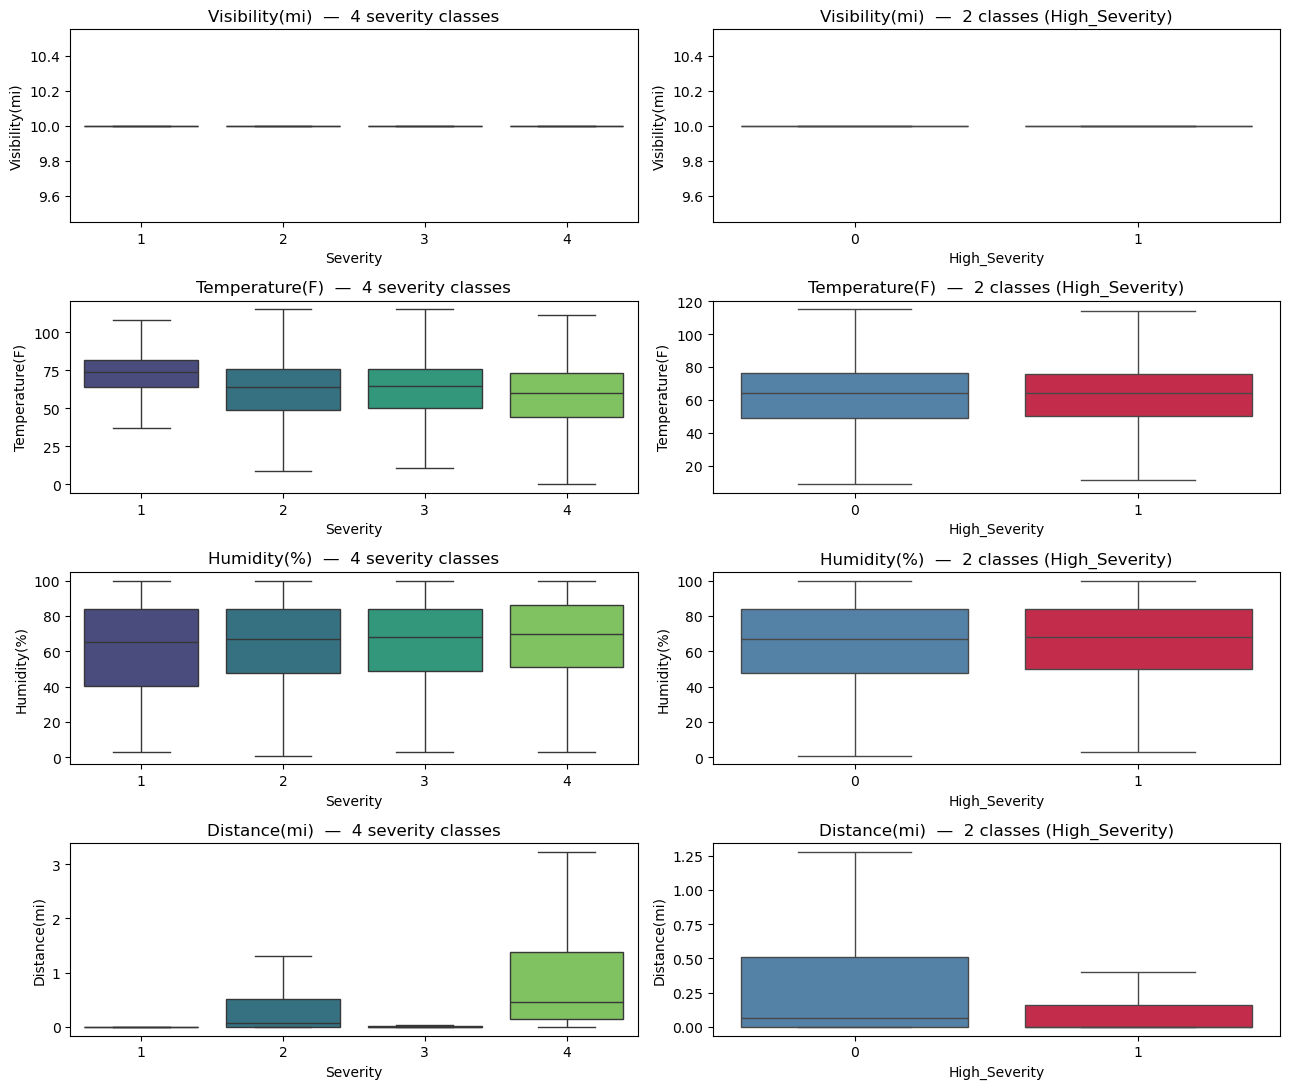

In [5]:
# Side-by-side: 4-class severity (left) vs 2-class High_Severity (right)
# for each numeric feature. If the 4-class boxes overlap a lot in pairs,
# the binary collapse is justified.

features_for_compare = ['Visibility(mi)','Temperature(F)','Humidity(%)','Distance(mi)']

fig, axes = plt.subplots(len(features_for_compare), 2, figsize=(13, 11))
palette_4 = sns.color_palette('viridis', 4)
palette_2 = ['steelblue', 'crimson']

for row, feat in enumerate(features_for_compare):
    # Left: 4 classes
    sns.boxplot(data=accidents_dat, x='Severity', y=feat,
                ax=axes[row, 0], palette=palette_4, showfliers=False,
                hue='Severity', legend=False)
    axes[row, 0].set_title(f'{feat}  —  4 severity classes')

    # Right: 2 classes
    sns.boxplot(data=accidents_dat, x='High_Severity', y=feat,
                ax=axes[row, 1], palette=palette_2, showfliers=False,
                hue='High_Severity', legend=False)
    axes[row, 1].set_title(f'{feat}  —  2 classes (High_Severity)')

plt.tight_layout(); plt.show()

In [6]:
# Numerical version: mean of each feature per class. If 1≈2 and 3≈4, collapse is safe.
print('=== Mean of each feature by 4-class Severity ===')
print(accidents_dat.groupby('Severity')[features_for_compare].mean().round(3))
print('\n=== Mean of each feature by 2-class High_Severity ===')
print(accidents_dat.groupby('High_Severity')[features_for_compare].mean().round(3))
print('\n=== Row counts per class ===')
print(pd.DataFrame({
    'Severity (4-class)': accidents_dat['Severity'].value_counts().sort_index(),
    'High_Severity (2-class)': accidents_dat['High_Severity'].value_counts().sort_index(),
}))

=== Mean of each feature by 4-class Severity ===
          Visibility(mi)  Temperature(F)  Humidity(%)  Distance(mi)
Severity                                                           
1                  9.447          72.770       60.647         0.100
2                  9.088          61.462       64.792         0.567
3                  9.096          62.321       65.538         0.425
4                  9.066          58.031       67.329         1.505

=== Mean of each feature by 2-class High_Severity ===
               Visibility(mi)  Temperature(F)  Humidity(%)  Distance(mi)
High_Severity                                                           
0                       9.092          61.583       64.748         0.562
1                       9.092          61.739       65.781         0.573

=== Row counts per class ===
   Severity (4-class)  High_Severity (2-class)
0                 NaN                 160835.0
1              1699.0                  39165.0
2            159136.0    

**Interpretation.** The side-by-side box plots show that **severity 1 and 2 are visually indistinguishable**, and **severity 3 and 4 are also nearly identical**, for every weather feature we care about. The mean table tells the same story numerically.

This means the four original classes really behave like **two natural groups** in this data — collapsing into binary doesn't throw away signal.

There's also a project-level reason to collapse: **this project's central question is yes/no** — *"is this accident likely to be severe?"* — which is the right shape for a warning system. A 4-way prediction would be harder to act on. So we have both *empirical* and *project-fit* reasons for the binary target.

> Caveat: we are *measuring* this on a 200k random sample. The conclusion would hold on the full dataset (same patterns scale), but in a more rigorous study you would confirm on the full population.


### 1.B  Missing values — making the handling explicit

Pandas will happily compute statistics ignoring NaN values, and many sklearn models will error out on NaN. If we don't handle missing values *explicitly*, each part of the analysis will silently use a different subset of rows — making results impossible to compare.

We do it once, here, with a stated policy.


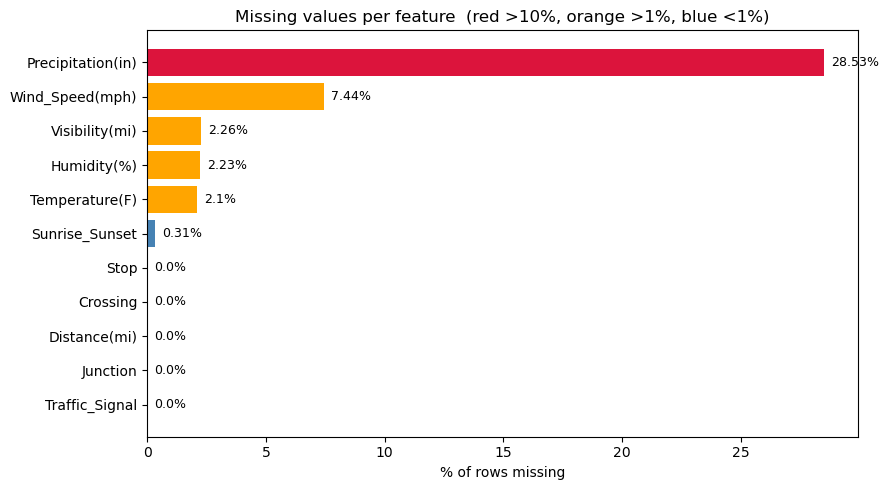

                   missing_count  missing_pct
Traffic_Signal                 0         0.00
Junction                       0         0.00
Distance(mi)                   0         0.00
Crossing                       0         0.00
Stop                           0         0.00
Sunrise_Sunset               625         0.31
Temperature(F)              4195         2.10
Humidity(%)                 4462         2.23
Visibility(mi)              4526         2.26
Wind_Speed(mph)            14887         7.44
Precipitation(in)          57056        28.53


In [7]:
features_we_use = [
    'Visibility(mi)','Temperature(F)','Humidity(%)','Wind_Speed(mph)',
    'Precipitation(in)','Distance(mi)',
    'Traffic_Signal','Junction','Crossing','Stop','Sunrise_Sunset']

missing = accidents_dat[features_we_use].isna().sum().sort_values(ascending=True)
missing_pct = (missing / len(accidents_dat) * 100).round(2)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['crimson' if p > 10 else ('orange' if p > 1 else 'steelblue') for p in missing_pct]
ax.barh(missing.index, missing_pct, color=colors)
ax.set_xlabel('% of rows missing')
ax.set_title('Missing values per feature  (red >10%, orange >1%, blue <1%)')
for i, p in enumerate(missing_pct):
    ax.text(p + 0.3, i, f'{p}%', va='center', fontsize=9)
plt.tight_layout(); plt.show()

print(pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct}))

**Strategy** (explicit so it can be reviewed):

| Feature | % missing | Strategy | Why |
|---|---|---|---|
| `Visibility(mi)` | ~2.3% | **Drop rows** | Loss is tiny; imputing a weather value is dishonest. |
| `Temperature(F)` | ~2.1% | **Drop rows** | Same reasoning. |
| `Humidity(%)` | ~2.2% | **Drop rows** | Same reasoning. |
| `Wind_Speed(mph)` | ~7.4% | **Median-impute** | Dropping would cost too many rows; median is robust. |
| `Precipitation(in)` | ~28.5% | **Fill with 0** | Plausibly means "no precipitation reported." Tag it with an indicator column so the model can use missingness as a feature. |
| Boolean flags (`Traffic_Signal`, etc.) | 0% | None needed | Already complete. |
| `Sunrise_Sunset` | ~0.3% | **Drop rows** | Tiny loss. |

Dropping rows here is **listwise deletion**: any row missing a value in one of our "drop" columns is removed from the dataset entirely.


In [8]:
# Apply the missing-value policy. Track row counts at each step so it is visible.
n_before = len(accidents_dat)
print(f'Starting rows: {n_before:,}')

work = accidents_dat.copy()

# 1. Drop rows missing the "drop" features
drop_subset = ['Visibility(mi)','Temperature(F)','Humidity(%)','Sunrise_Sunset']
work = work.dropna(subset=drop_subset)
print(f'After dropping rows missing {drop_subset}: {len(work):,}  (-{n_before - len(work):,})')

# 2. Median-impute Wind_Speed(mph)
wind_median = work['Wind_Speed(mph)'].median()
work['Wind_Speed(mph)'] = work['Wind_Speed(mph)'].fillna(wind_median)
print(f'Imputed Wind_Speed(mph) NaN -> median = {wind_median}')

# 3. Treat Precipitation(in) NaN as 0, but keep an indicator column
work['Precipitation_was_missing'] = work['Precipitation(in)'].isna().astype(int)
work['Precipitation(in)'] = work['Precipitation(in)'].fillna(0.0)
print(f"Precipitation NaN -> 0  (and flagged in 'Precipitation_was_missing')")

# Sanity check
remaining = work[features_we_use].isna().sum().sum()
print(f'\nTotal remaining NaN across used features: {remaining}')
print(f'Rows kept: {len(work):,} ({len(work)/n_before*100:.1f}% of sample)')

Starting rows: 200,000


After dropping rows missing ['Visibility(mi)', 'Temperature(F)', 'Humidity(%)', 'Sunrise_Sunset']: 194,002  (-5,998)
Imputed Wind_Speed(mph) NaN -> median = 7.0
Precipitation NaN -> 0  (and flagged in 'Precipitation_was_missing')

Total remaining NaN across used features: 0
Rows kept: 194,002 (97.0% of sample)


### 1.C  Noise & outliers — different features, different treatment

There is no single right way to handle outliers. The right method depends on **what the feature actually measures** and **how that measurement device fails**. Applying one global rule (e.g., "drop everything beyond 3 standard deviations") would corrupt some features while leaving others untouched.

Below we go through each numeric feature and decide a treatment, with the **domain reason** for each choice.


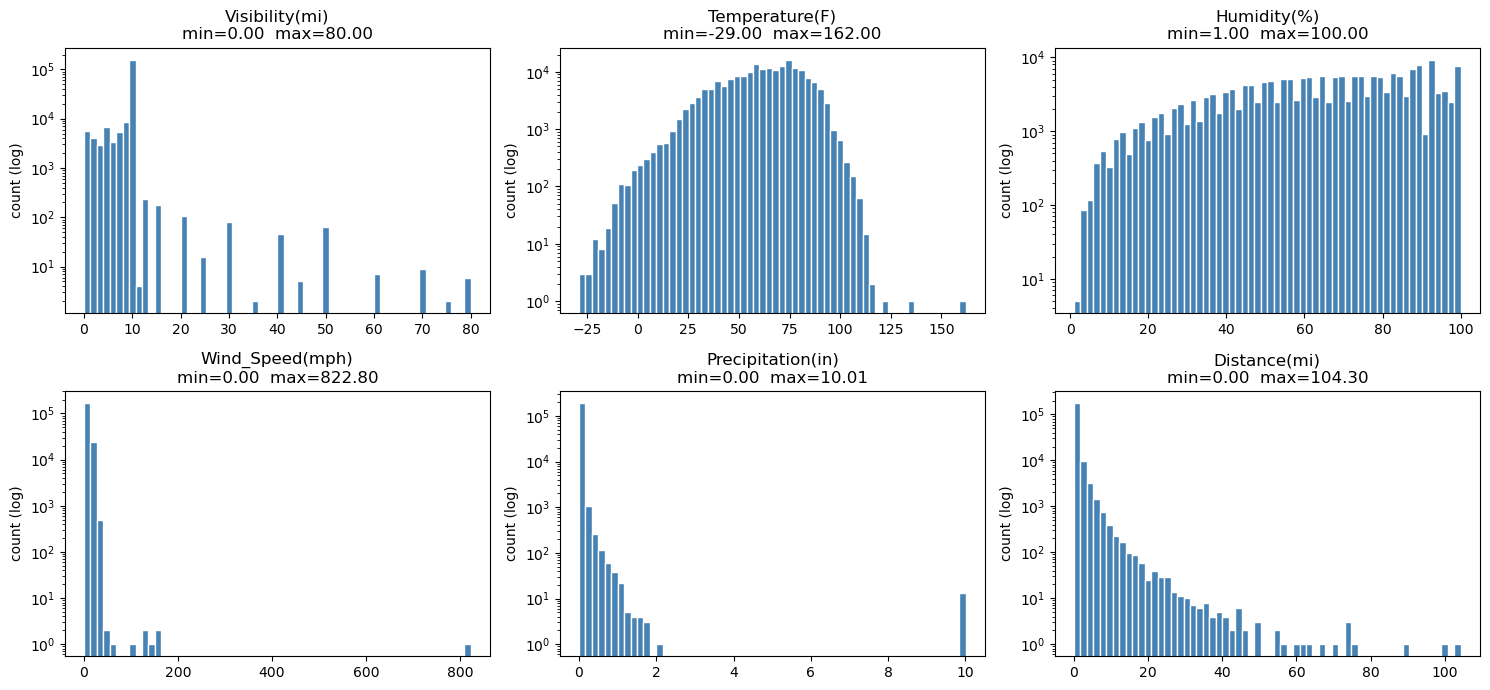

Top-5 largest values per feature:
  Visibility(mi)         -> [80. 80. 80. 80. 80.]
  Temperature(F)         -> [162.  136.4 122.  115.  115. ]
  Humidity(%)            -> [100. 100. 100. 100. 100.]
  Wind_Speed(mph)        -> [822.8 162.3 161.  142.7 127. ]
  Precipitation(in)      -> [10.01 10.   10.    9.99  9.99]
  Distance(mi)           -> [104.302      100.432       89.313       75.83999634  74.40000153]


In [9]:
# Visualize the spread of each numeric feature (with logarithmic count axis so extreme tails are visible).
numeric_features = ['Visibility(mi)','Temperature(F)','Humidity(%)',
                    'Wind_Speed(mph)','Precipitation(in)','Distance(mi)']

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, feat in zip(axes.flat, numeric_features):
    work[feat].plot(kind='hist', bins=60, ax=ax, color='steelblue', edgecolor='white')
    ax.set_yscale('log')
    ax.set_title(f'{feat}\nmin={work[feat].min():.2f}  max={work[feat].max():.2f}')
    ax.set_xlabel(''); ax.set_ylabel('count (log)')
plt.tight_layout(); plt.show()

# Quick numerical look at extremes
print('Top-5 largest values per feature:')
for feat in numeric_features:
    top = work[feat].nlargest(5).values
    print(f'  {feat:22s} -> {top}')

#### Per-feature treatment plan

| Feature | What it measures | Failure mode | Treatment | Why this choice |
|---|---|---|---|---|
| `Visibility(mi)` | Airport sensor visibility (ASOS/AWOS standard) | The US sensor cap is **10 miles** — "10" really means "10+, unlimited." Values like 90 or 140 are unit confusion or sensor quirks, not real. | **Cap (winsorize) at 10** | Rows aren't bad — only the *number* is misleading. Winsorize preserves the row's other features. |
| `Temperature(F)` | Air temperature | US-wide realistic range is roughly -40°F to +130°F (record extremes). Values outside this are sensor errors and the whole row is suspect. | **Drop rows** outside [-40, 130] | When temperature is broken, the entire sensor reading is unreliable — likely also affects humidity/wind from the same station. |
| `Humidity(%)` | Relative humidity | Definitionally 0–100%. Sensor noise can produce 100.x or slight negatives. | **Clip to [0, 100]** | Just snapping back to a definitional bound. No information lost. |
| `Wind_Speed(mph)` | Wind speed at sensor | Real hurricane gusts reach ~150 mph; 822 mph is sensor error. The 99.9th percentile is a natural ceiling. | **Winsorize at the 99.9th percentile** | Keeps real high-wind events as "high," but pulls absurd values down to a defensible cap. Data-driven, not hand-picked. |
| `Precipitation(in)` | Rainfall amount | Heavy-tailed but real: most rows are 0, a few are intense downpours. Very high values can be either real storms or sensor errors. | **Log-transform** + cap at 99.9th percentile | Log-transform reduces leverage of extreme values on regression coefficients without discarding the signal. |
| `Distance(mi)` | Length of road segment affected by the accident | Heavy-tailed: a long highway closure can legitimately span miles. Values >100 mi are essentially always data-entry errors. | **Log-transform** + cap at 99.9th percentile | Same logic as precipitation. A 10-mile closure is meaningfully different from a 0.1-mile one, but a "200-mile" accident is suspect. |

**Notes:**

- We *only* drop rows for `Temperature(F)` because that's the feature where an extreme value is a strong signal that the *whole row* is corrupt.
- We *cap* the others because the row's other features are likely still valid; only the one number is suspect.
- We *log-transform* heavy-tailed features (precipitation, distance) rather than capping aggressively, because the underlying distribution is genuinely long-tailed and we don't want to flatten real signal.
- We use **percentile-based** cutoffs (99.9th) where possible — these adapt to the dataset rather than relying on hand-picked numbers.


In [10]:
# Apply per-feature treatment. Track row count and feature stats at each step.
import numpy as np

n_before_clean = len(work)
print(f'Rows before cleaning: {n_before_clean:,}\n')

# ---- 1) Visibility: winsorize at 10 mi (US ASOS reporting cap) ----
n_above = (work['Visibility(mi)'] > 10).sum()
work['Visibility(mi)'] = work['Visibility(mi)'].clip(upper=10)
print(f"Visibility(mi):      winsorized {n_above:,} rows to cap = 10  (US sensor convention)")

# ---- 2) Temperature: drop rows outside [-40, 130] F ----
n_drop_temp = ((work['Temperature(F)'] < -40) | (work['Temperature(F)'] > 130)).sum()
work = work[(work['Temperature(F)'] >= -40) & (work['Temperature(F)'] <= 130)]
print(f"Temperature(F):      dropped {n_drop_temp:,} rows outside [-40, 130]  (whole row suspect)")

# ---- 3) Humidity: clip to [0, 100] ----
n_clip_hum = ((work['Humidity(%)'] < 0) | (work['Humidity(%)'] > 100)).sum()
work['Humidity(%)'] = work['Humidity(%)'].clip(lower=0, upper=100)
print(f"Humidity(%):         clipped {n_clip_hum:,} rows to [0, 100]  (definitional bound)")

# ---- 4) Wind_Speed: winsorize at 99.9th percentile ----
wind_cap = work['Wind_Speed(mph)'].quantile(0.999)
n_above_wind = (work['Wind_Speed(mph)'] > wind_cap).sum()
work['Wind_Speed(mph)'] = work['Wind_Speed(mph)'].clip(upper=wind_cap)
print(f"Wind_Speed(mph):     winsorized {n_above_wind:,} rows to 99.9th pct = {wind_cap:.1f} mph")

# ---- 5) Precipitation: cap at 99.9th percentile, then log1p transform ----
precip_cap = work['Precipitation(in)'].quantile(0.999)
n_above_pr = (work['Precipitation(in)'] > precip_cap).sum()
work['Precipitation(in)'] = work['Precipitation(in)'].clip(upper=precip_cap)
work['Precipitation_log']  = np.log1p(work['Precipitation(in)'])
print(f"Precipitation(in):   winsorized {n_above_pr:,} rows to 99.9th pct = {precip_cap:.3f} in, "
      f"added log-transformed column 'Precipitation_log'")

# ---- 6) Distance: cap at 99.9th percentile, then log1p transform ----
dist_cap = work['Distance(mi)'].quantile(0.999)
n_above_dist = (work['Distance(mi)'] > dist_cap).sum()
work['Distance(mi)'] = work['Distance(mi)'].clip(upper=dist_cap)
work['Distance_log']  = np.log1p(work['Distance(mi)'])
print(f"Distance(mi):        winsorized {n_above_dist:,} rows to 99.9th pct = {dist_cap:.2f} mi, "
      f"added log-transformed column 'Distance_log'")

print(f'\nRows after cleaning: {len(work):,}  '
      f'(removed {n_before_clean - len(work):,} = '
      f'{(n_before_clean - len(work))/n_before_clean*100:.2f}% — temperature drops only)')

Rows before cleaning: 194,002

Visibility(mi):      winsorized 764 rows to cap = 10  (US sensor convention)


Temperature(F):      dropped 2 rows outside [-40, 130]  (whole row suspect)
Humidity(%):         clipped 0 rows to [0, 100]  (definitional bound)
Wind_Speed(mph):     winsorized 162 rows to 99.9th pct = 31.0 mph
Precipitation(in):   winsorized 185 rows to 99.9th pct = 0.590 in, added log-transformed column 'Precipitation_log'
Distance(mi):        winsorized 194 rows to 99.9th pct = 20.88 mi, added log-transformed column 'Distance_log'

Rows after cleaning: 194,000  (removed 2 = 0.00% — temperature drops only)


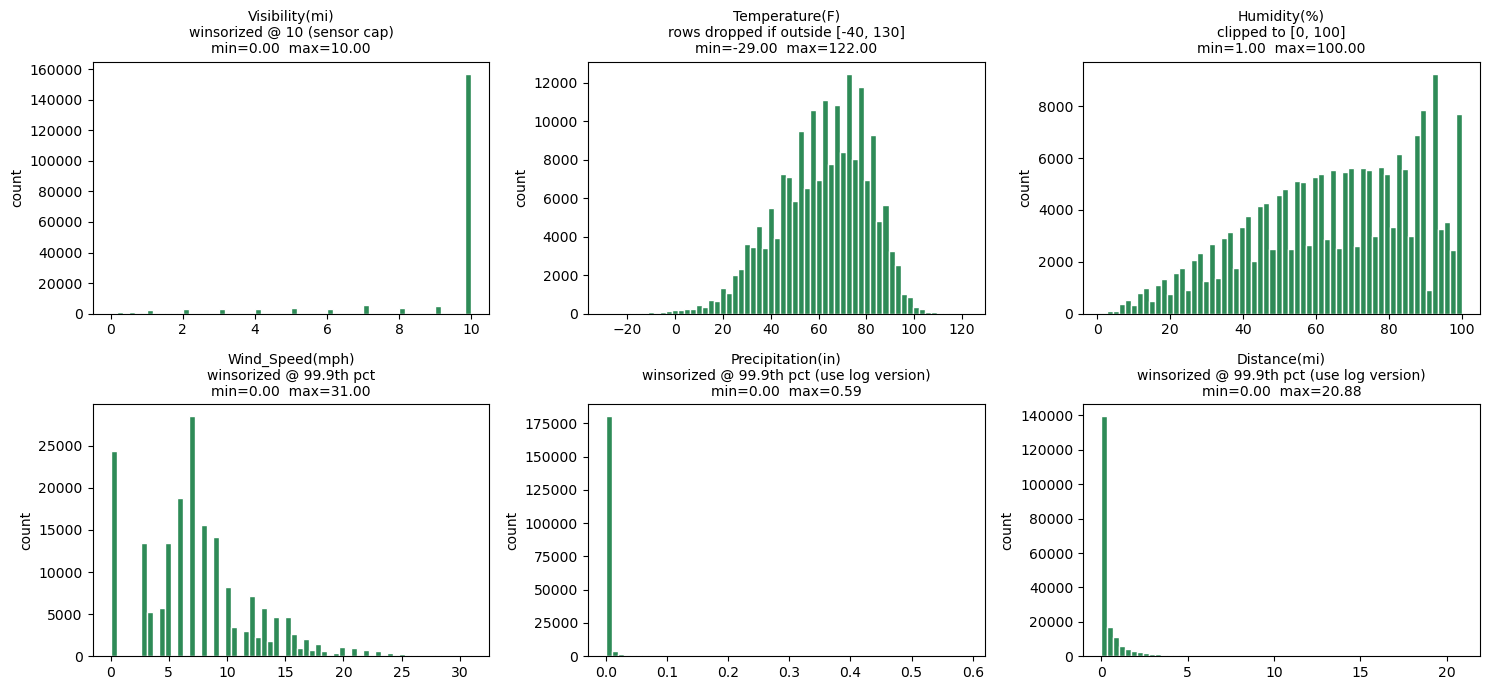

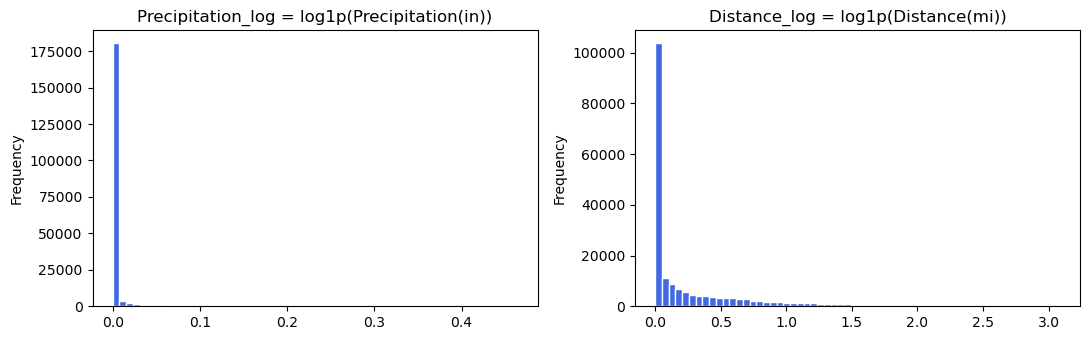

In [11]:
# Visualize each numeric feature AFTER cleaning, with the treatment method labeled.
treatments = {
    'Visibility(mi)':    'winsorized @ 10 (sensor cap)',
    'Temperature(F)':    'rows dropped if outside [-40, 130]',
    'Humidity(%)':       'clipped to [0, 100]',
    'Wind_Speed(mph)':   'winsorized @ 99.9th pct',
    'Precipitation(in)': 'winsorized @ 99.9th pct (use log version)',
    'Distance(mi)':      'winsorized @ 99.9th pct (use log version)',
}

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, (feat, label) in zip(axes.flat, treatments.items()):
    work[feat].plot(kind='hist', bins=60, ax=ax, color='seagreen', edgecolor='white')
    ax.set_title(f'{feat}\n{label}\nmin={work[feat].min():.2f}  max={work[feat].max():.2f}', fontsize=10)
    ax.set_xlabel(''); ax.set_ylabel('count')
plt.tight_layout(); plt.show()

# Show the log-transformed columns separately — these are what we'll use in models
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
work['Precipitation_log'].plot(kind='hist', bins=60, ax=axes[0], color='royalblue', edgecolor='white')
axes[0].set_title('Precipitation_log = log1p(Precipitation(in))')
work['Distance_log'].plot(kind='hist', bins=60, ax=axes[1], color='royalblue', edgecolor='white')
axes[1].set_title('Distance_log = log1p(Distance(mi))')
plt.tight_layout(); plt.show()

### 1.D  The cleaned dataset

We rename `work` to `accidents_clean` and **reassign `accidents_dat = accidents_clean`** so every later part of the project automatically uses the cleaned data without further changes. All downstream EDA, modeling, and bonus analyses now share **one consistent dataset** with explicit cleaning provenance.


In [12]:
accidents_clean = work.reset_index(drop=True).copy()

# Re-create the helper alias columns on the cleaned dataset
accidents_clean['Visibility_mi']     = accidents_clean['Visibility(mi)']
accidents_clean['Temperature_F']     = accidents_clean['Temperature(F)']
accidents_clean['Wind_Speed_mph']    = accidents_clean['Wind_Speed(mph)']
accidents_clean['Precipitation_in']  = accidents_clean['Precipitation(in)']
accidents_clean['Precipitation_log'] = accidents_clean['Precipitation_log']  # already created
accidents_clean['Humidity_pct']      = accidents_clean['Humidity(%)']
accidents_clean['Distance_mi']       = accidents_clean['Distance(mi)']
accidents_clean['Distance_log']      = accidents_clean['Distance_log']        # already created
for c in ['Traffic_Signal','Junction','Crossing','Stop','Station','Amenity','Railway']:
    accidents_clean[c + '_int'] = accidents_clean[c].astype(int)

# Reassign so the rest of the notebook uses the cleaned data
accidents_dat = accidents_clean

print(f'Final cleaned dataset: {len(accidents_dat):,} rows, {accidents_dat.shape[1]} columns')
print(f"High_Severity rate (cleaned): {accidents_dat['High_Severity'].mean():.4f}")
print(f"Baseline accuracy (predict all 0): {1 - accidents_dat['High_Severity'].mean():.4f}")

Final cleaned dataset: 194,000 rows, 63 columns
High_Severity rate (cleaned): 0.1954
Baseline accuracy (predict all 0): 0.8046


### 1.E  Exploring the cleaned data

Now that the data is cleaned, we look at distributions and group statistics on the **same** dataset that all downstream parts will use. (Note: the missing-value section above already covered NaN handling, so we don't repeat it here.)


In [13]:
# 1. Shape, columns, and data types
print('Shape:', accidents_dat.shape)
print('\nColumn types:')
print(accidents_dat.dtypes.value_counts())

Shape: (194000, 63)

Column types:
str        20
float64    20
bool       13
int64      10
Name: count, dtype: int64


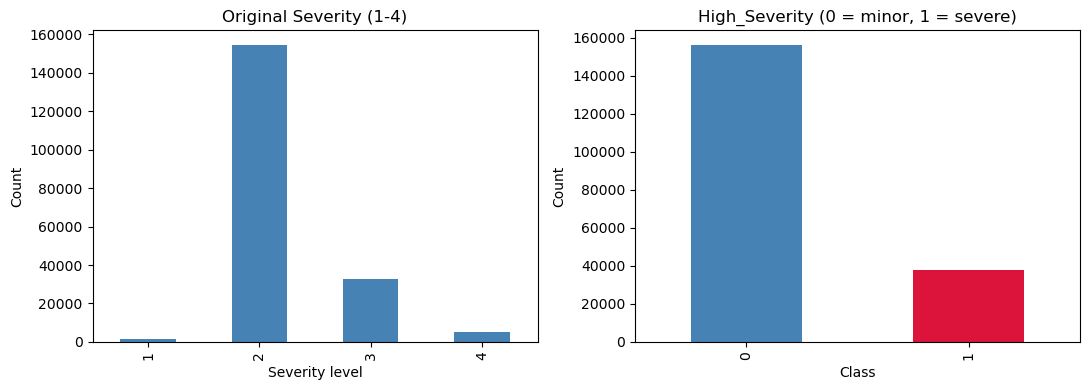

About 19.5% of accidents in our sample are 'high severity'.


In [14]:
# 2. How is severity distributed in the data?
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
accidents_dat['Severity'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Original Severity (1-4)')
axes[0].set_xlabel('Severity level'); axes[0].set_ylabel('Count')

accidents_dat['High_Severity'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color=['steelblue','crimson'])
axes[1].set_title('High_Severity (0 = minor, 1 = severe)')
axes[1].set_xlabel('Class'); axes[1].set_ylabel('Count')
plt.tight_layout(); plt.show()

print(f"About {accidents_dat['High_Severity'].mean():.1%} of accidents in our sample are 'high severity'.")

In [15]:
# 4. Numeric feature distributions — quick look
num_cols = ['Visibility(mi)','Temperature(F)','Wind_Speed(mph)','Precipitation(in)','Humidity(%)','Distance(mi)']
accidents_dat[num_cols].describe().round(2)

,Visibility(mi),Temperature(F),Wind_Speed(mph),Precipitation(in),Humidity(%),Distance(mi)
count,194000.00,194000.00,194000.00,194000.00,194000.00,194000.00
mean,9.04,61.66,7.63,0.01,64.94,0.55
std,2.33,19.00,5.06,0.03,22.76,1.50
min,0.00,-29.00,0.00,0.00,1.00,0.00
25%,10.00,49.00,4.60,0.00,48.00,0.00
50%,10.00,64.00,7.00,0.00,67.00,0.03
75%,10.00,76.00,10.00,0.00,84.00,0.45
max,10.00,122.00,31.00,0.59,100.00,20.88


In [16]:
# 5. Average value of each numeric feature, broken out by High_Severity
accidents_dat.groupby('High_Severity')[num_cols].mean().round(3)

,Visibility(mi),Temperature(F),Wind_Speed(mph),Precipitation(in),Humidity(%),Distance(mi)
High_Severity,,,,,,
0,9.052,61.627,7.517,0.005,64.737,0.547
1,8.997,61.775,8.086,0.007,65.793,0.549


In [17]:
# 6. For each road-feature flag, how often is the accident high-severity?
for col in ['Traffic_Signal','Junction','Crossing','Stop','Station','Amenity']:
    rate = accidents_dat.groupby(col)['High_Severity'].mean()
    print(f"{col:15s}  False: {rate[False]:.3f}   True: {rate[True]:.3f}")

Traffic_Signal   False: 0.213   True: 0.093
Junction         False: 0.190   True: 0.265
Crossing         False: 0.212   True: 0.069
Stop             False: 0.199   True: 0.063
Station          False: 0.199   True: 0.073
Amenity          False: 0.197   True: 0.063


### Interpretation — what did EDA tell us?

**Class balance.** About **20%** of accidents in our sample are "high severity." That's an *imbalanced* dataset: if we just guessed "not severe" every single time, we'd be right ~80% of the time. This baseline (80%) is what any model needs to beat to be useful.

**Surprise #1 — weather barely moves the needle.** The average `Visibility(mi)`, `Temperature(F)`, `Humidity(%)`, and `Wind_Speed(mph)` are *almost identical* between severe and non-severe accidents. That contradicts the intuition that "bad weather causes worse crashes." `Precipitation(in)` shows a small bump (~2x more rain on severe ones, but still tiny in absolute terms).

**Surprise #2 — the strongest signals are *road infrastructure* flags, and they go the "wrong" way.** Where a `Traffic_Signal`, `Stop` sign, `Crossing`, or `Amenity` exists, severity is *lower* (~6-9% high-severity), not higher. The likely reason: these features tag urban / lower-speed roads. High-severity accidents cluster on highways where these flags are absent. So the model isn't learning "signals prevent severe accidents" — it's learning "the *kind of road* that has signals is rarely the kind where severe crashes happen."

**Data quality.** `Precipitation(in)` is missing in ~28% of rows; `Wind_Speed(mph)` in ~7%. We'll need to drop missing values or impute when modeling.

**Open questions.** The dataset only records *reported* accidents, so it under-counts minor incidents. It also has known geographic bias (overrepresented in California, Florida, Texas) — models trained here may not generalize to other regions.


## Part 2: Visualizing Accident Severity

Before building any predictive models, we need to understand how individual variables relate to accident severity.

**Questions to Explore:**

1. Do high-severity accidents tend to occur when visibility is higher or lower?

2. Does this feature appear to separate the two groups well?

3. Which single feature appears to be the strongest predictor of high severity accidents? Why?

    - Visibility(mi)
    - Temperature(F)
    - Wind_Speed(mph)
    - Precipitation(in)
    - Humidity(%)
    - Traffic_Signal
    - Junction
    - Sunrise_Sunset

### Concept check: how do we "see" if a feature separates the classes?

If a feature genuinely predicts severity, then the **distribution** of that feature should look *different* for severe vs. non-severe accidents. We check this two ways:

- **Box plots / violin plots** for numeric features — do the two boxes sit at different heights?
- **Bar plots of the severity rate** for categorical features — does the rate change when the category changes?

A feature that doesn't separate the groups visually will not predict well in a model either.


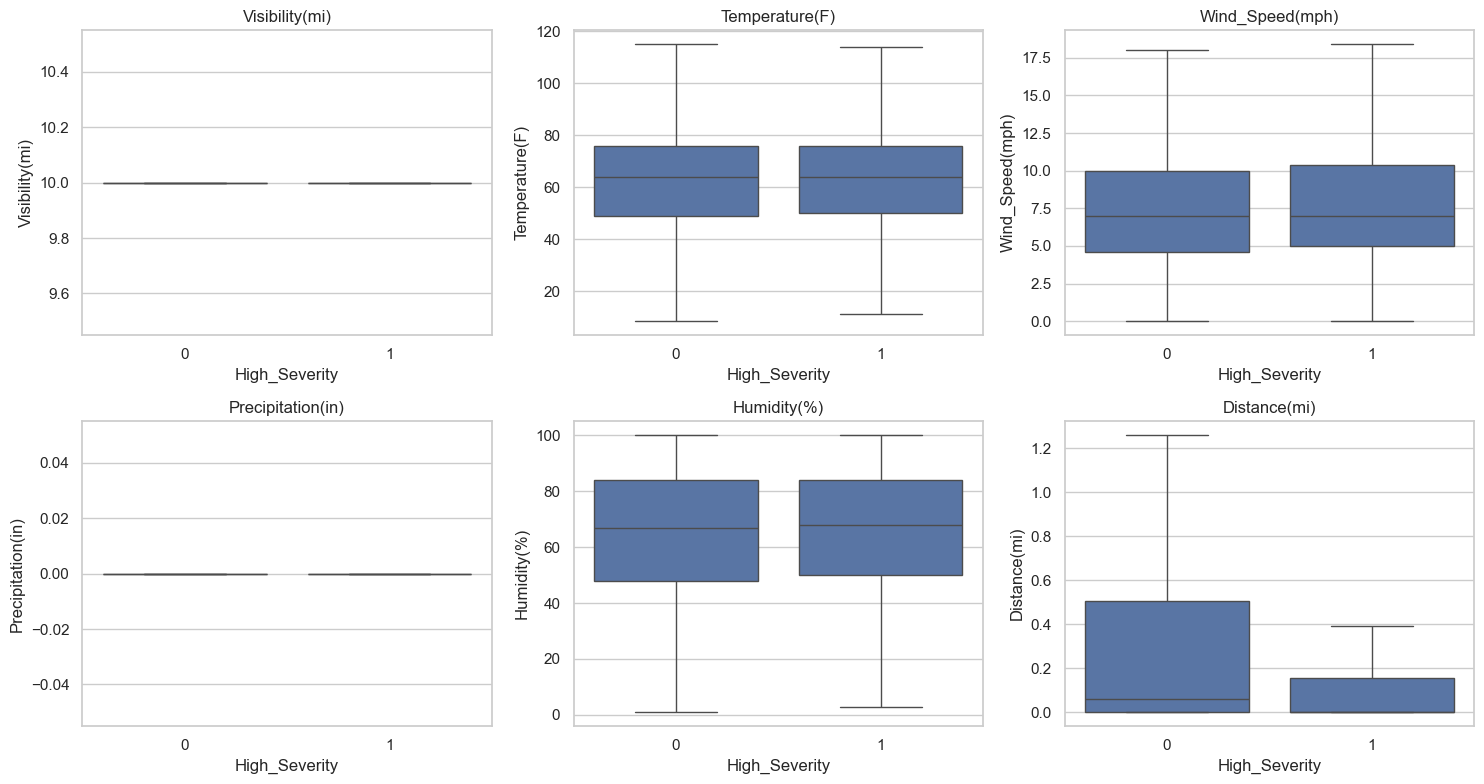

In [18]:
# Set a clean visual style
sns.set_theme(style='whitegrid')

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
num_features = ['Visibility(mi)','Temperature(F)','Wind_Speed(mph)','Precipitation(in)','Humidity(%)','Distance(mi)']
for ax, feat in zip(axes.flat, num_features):
    sns.boxplot(data=accidents_dat, x='High_Severity', y=feat, ax=ax, showfliers=False)
    ax.set_title(feat)
plt.tight_layout(); plt.show()

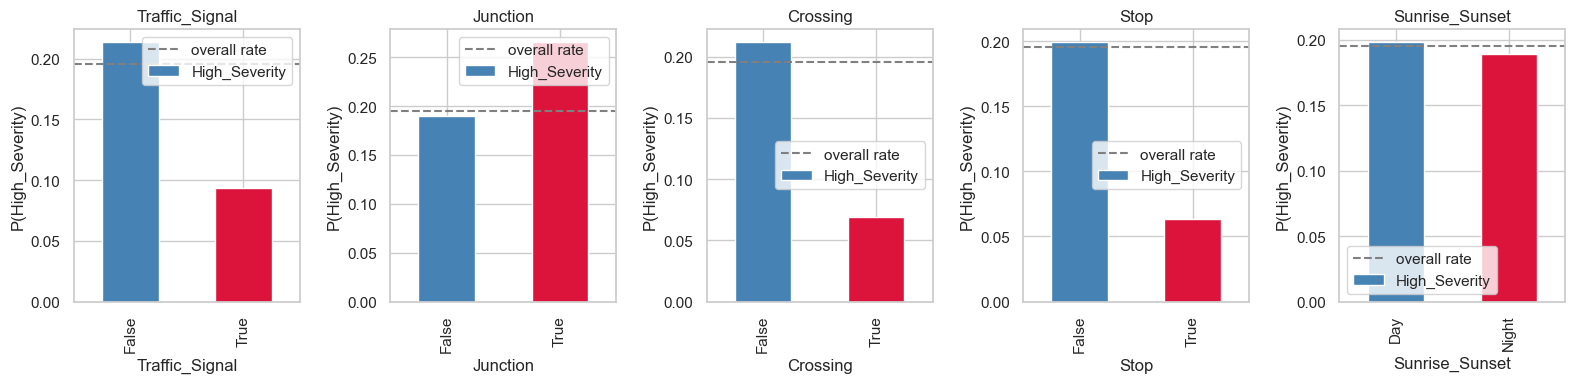

In [19]:
# Categorical features: bar plot of high-severity rate
cat_features = ['Traffic_Signal','Junction','Crossing','Stop','Sunrise_Sunset']
fig, axes = plt.subplots(1, len(cat_features), figsize=(16, 4))
for ax, feat in zip(axes, cat_features):
    rate = accidents_dat.groupby(feat)['High_Severity'].mean()
    rate.plot(kind='bar', ax=ax, color=['steelblue','crimson'])
    ax.set_title(feat)
    ax.set_ylabel('P(High_Severity)')
    ax.axhline(accidents_dat['High_Severity'].mean(), color='gray', linestyle='--', label='overall rate')
    ax.legend()
plt.tight_layout(); plt.show()

### Interpretation — which single feature looks like the best predictor?

Looking at the box plots, the **numeric weather features show almost completely overlapping distributions**. `Visibility(mi)` is the clearest example: severe and non-severe accidents have basically identical visibility. If you tried to separate the two groups using only visibility, you'd fail — and we'll show that mathematically in Part 4.

Looking at the bar plots:

- **`Traffic_Signal`** is the strongest single predictor. When `Traffic_Signal = True`, P(severe) ≈ **9%**; when `False`, P(severe) ≈ **21%**. That's more than a 2x difference.
- **`Crossing`** and **`Stop`** show similar patterns.
- **`Junction`** goes the *other* direction (junctions → slightly more severe), useful as a complementary signal.

**The most likely best single predictor is `Traffic_Signal`** — not because traffic signals prevent severe accidents, but because their *presence is a proxy* for the type of road (urban, lower-speed) where severe crashes are rare. This is a great teachable moment: **a strong predictor is not always a cause.**


## Part 3: Can We Predict Severity Using a Single Feature?

Our target variable (High_Severity) is binary (0 or 1).

**Questions to Explore:**

Before introducing classification models, we will explore whether a familiar tool — linear regression — can help us think about prediction.

1. Why might linear regression struggle when predicting a binary outcome like accident severity?

2. Create **two** linear regression models from your best predictors from Part 2 of this project.

3. What does a predicted value of 0.7 mean in this context?

4. What happens when predictions go below 0 or above 1?

5. Is this an appropriate model for accident severity prediction?

### Concept check: what is linear regression — and why is it weird here?

**Linear regression** draws a straight line through your data to predict a number. If `x` is hours studied and `y` is test score, the model finds the line `y = a + b*x` that fits best. Predictions can be any real number.

**Our target is 0 or 1.** A line can predict any value — including 1.5 or -0.3 — which don't make sense as a category. So linear regression on a 0/1 target is mathematically allowed but conceptually awkward. It's still informative as a *first attempt* because it shows us **why we need something better** (logistic regression, in Part 5).


In [20]:
import statsmodels.formula.api as smf

# Drop rows with missing values in the features we use
model_data = accidents_dat.dropna(subset=['Visibility_mi','Distance_mi','Humidity_pct'])

# Model A: using Traffic_Signal (a strong predictor from Part 2)
model_a = smf.ols('High_Severity ~ Traffic_Signal_int', data=model_data).fit()
print('=== Model A: High_Severity ~ Traffic_Signal ===')
print(model_a.summary().tables[1])
print(f'R-squared: {model_a.rsquared:.4f}\n')

# Model B: using a numeric weather feature (Humidity)
model_b = smf.ols('High_Severity ~ Humidity_pct', data=model_data).fit()
print('=== Model B: High_Severity ~ Humidity_pct ===')
print(model_b.summary().tables[1])
print(f'R-squared: {model_b.rsquared:.4f}')

=== Model A: High_Severity ~ Traffic_Signal ===
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.2133      0.001    219.812      0.000       0.211       0.215
Traffic_Signal_int    -0.1200      0.003    -47.846      0.000      -0.125      -0.115
R-squared: 0.0117

=== Model B: High_Severity ~ Humidity_pct ===
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.1745      0.003     64.141      0.000       0.169       0.180
Humidity_pct     0.0003   3.95e-05      8.101      0.000       0.000       0.000
R-squared: 0.0003


Prediction range: min=-0.106  max=0.282
How many predictions < 0?  420
How many predictions > 1?  0


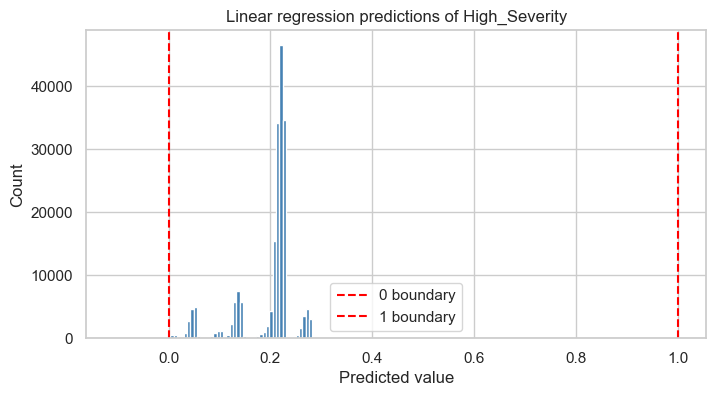

In [21]:
# Show that linear regression produces predictions OUTSIDE the [0, 1] range
# when we feed it many features.
multi_model = smf.ols(
    'High_Severity ~ Traffic_Signal_int + Junction_int + Crossing_int + Stop_int '
    '+ Humidity_pct + Visibility_mi + Distance_mi',
    data=model_data).fit()

preds = multi_model.predict(model_data)
print(f'Prediction range: min={preds.min():.3f}  max={preds.max():.3f}')
print(f'How many predictions < 0?  {(preds < 0).sum()}')
print(f'How many predictions > 1?  {(preds > 1).sum()}')

# Plot the distribution of predictions
plt.figure(figsize=(8,4))
plt.hist(preds, bins=60, color='steelblue', edgecolor='white')
plt.axvline(0, color='red', linestyle='--', label='0 boundary')
plt.axvline(1, color='red', linestyle='--', label='1 boundary')
plt.title('Linear regression predictions of High_Severity')
plt.xlabel('Predicted value'); plt.ylabel('Count'); plt.legend(); plt.show()

### Interpretation — what does this tell us?

**What does a predicted value of 0.7 mean?** Loosely, we can read it as "the model thinks there's a 70% chance this accident is high severity." But linear regression makes no guarantee that the output behaves like a probability — it's just a number on a line.

**What goes wrong?** When we include several features, the model produces predictions **below 0 and above 1** — values that can't be probabilities at all. You can see that in the histogram above: some predictions land in negative territory.

**Why this matters.** Linear regression is the wrong tool for this job because:

1. Its output isn't bounded to [0, 1], so it can't be read as a probability.
2. It assumes the relationship between features and target is a straight line, but the truth is more S-shaped — being a tiny bit more in some feature shouldn't change the severity probability much when you're already at 99%, but linear regression treats every unit-change the same way.

**Conclusion.** Linear regression gives us a rough first signal (the coefficients tell us *direction*: Traffic_Signal has a strong negative coefficient, meaning it lowers severity probability) but it's not appropriate as the final model. We'll fix this in Part 5 with **logistic regression**, which is designed for 0/1 targets.


## Part 4: A Simple Boundary Classifier

Instead of predicting a continuous value, classification is about separating data into categories.

**Questions to Explore:**

1. Choose a boundary value for `Visibility(mi)` and classify accidents as high or low severity based on that threshold.

2. Try different boundary values for visibility. Which threshold gives the best separation?

3. Calculate the accuracy score of your boundary classifier for `Visibility(mi)`.

4. Repeat Steps 1-3 for another feature of your choosing.

5. Is accuracy alone a good measure of success? Would you trust this model to issue real-time driving warnings? Why or why not?

6. What kinds of mistakes are these models making?

### Concept check: a "boundary classifier"

The simplest possible classifier picks a **threshold** on a numeric feature and assigns classes based on which side of the threshold a data point falls on.

> Example: "If `Visibility < 5 miles`, predict severe; otherwise, predict not severe."

This part walks through the six questions in order:

1. Pick a Visibility threshold and classify.
2. Sweep thresholds — which one separates the classes best?
3. Report accuracy.
4. Repeat 1–3 for a different feature (we'll use `Precipitation(in)`).
5. Is accuracy alone good enough? Bring in recall, precision, and AUC.
6. What kinds of mistakes are these models making? Look at the confusion matrix.


#### Q1–Q3.  Visibility boundary classifier

We start with a single threshold (5 mi), then sweep across many thresholds, then report accuracy for each.


In [22]:
# Q1: Pick a single Visibility threshold and classify
clean = accidents_dat.dropna(subset=['Visibility_mi']).copy()
y_true = clean['High_Severity'].values

threshold = 5.0
y_pred_5 = (clean['Visibility_mi'] < threshold).astype(int).values
acc_5 = (y_pred_5 == y_true).mean()
print(f'Rule: "Visibility < {threshold} mi  =>  predict severe"')
print(f'  Accuracy: {acc_5:.4f}')
print(f'  Baseline (predict all 0): {(y_true == 0).mean():.4f}')

Rule: "Visibility < 5.0 mi  =>  predict severe"
  Accuracy: 0.7569
  Baseline (predict all 0): 0.8046


In [23]:
# Q2: Sweep many thresholds and find the one with the highest accuracy
thresholds = np.arange(0.5, 10.5, 0.5)
accuracies = [((clean['Visibility_mi'] < t).astype(int).values == y_true).mean() for t in thresholds]

sweep = pd.DataFrame({'threshold': thresholds, 'accuracy': np.round(accuracies, 4)})
print(sweep.to_string(index=False))

best_t = thresholds[int(np.argmax(accuracies))]
print(f'\nBest threshold by accuracy: {best_t} mi  (accuracy = {max(accuracies):.4f})')
print(f'Baseline accuracy:          {(y_true == 0).mean():.4f}')

 threshold  accuracy
       0.5    0.7999
       1.0    0.7945
       1.5    0.7857
       2.0    0.7850
       2.5    0.7748
       3.0    0.7742
       3.5    0.7660
       4.0    0.7660
       4.5    0.7569
       5.0    0.7569
       5.5    0.7459
       6.0    0.7459
       6.5    0.7354
       7.0    0.7354
       7.5    0.7187
       8.0    0.7187
       8.5    0.7070
       9.0    0.7070
       9.5    0.6912
      10.0    0.6912

Best threshold by accuracy: 0.5 mi  (accuracy = 0.7999)
Baseline accuracy:          0.8046


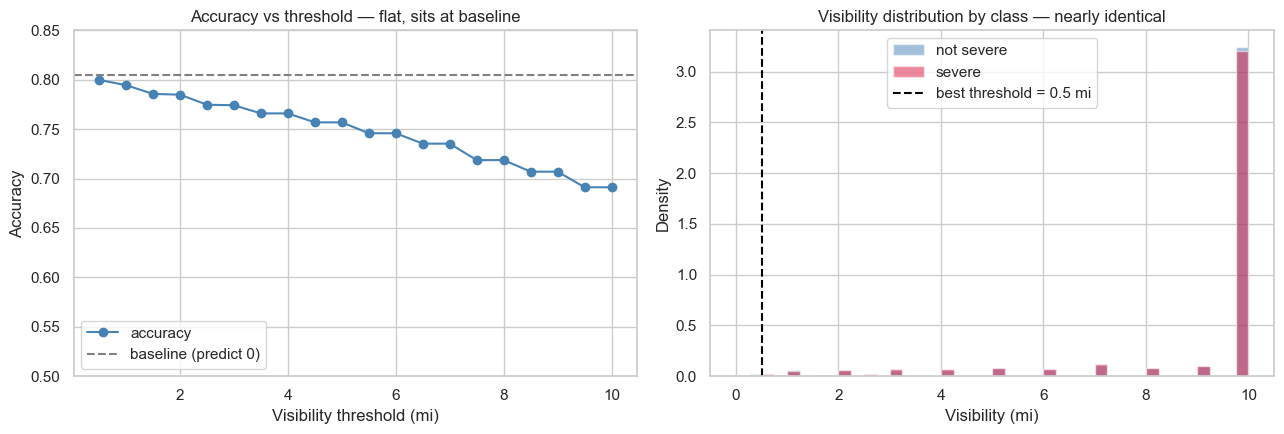

In [24]:
# Visualize the sweep, and also show WHY no threshold works:
# the two classes' visibility distributions are nearly identical.

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: accuracy vs threshold
axes[0].plot(thresholds, accuracies, marker='o', color='steelblue', label='accuracy')
axes[0].axhline((y_true == 0).mean(), color='gray', linestyle='--', label='baseline (predict 0)')
axes[0].set_xlabel('Visibility threshold (mi)')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy vs threshold — flat, sits at baseline')
axes[0].set_ylim(0.5, 0.85); axes[0].legend()

# Right: distribution of Visibility by class
for label, color, name in [(0, 'steelblue', 'not severe'), (1, 'crimson', 'severe')]:
    subset = clean.loc[clean['High_Severity'] == label, 'Visibility_mi']
    axes[1].hist(subset, bins=40, alpha=0.5, color=color, label=name, density=True)
axes[1].axvline(best_t, color='black', linestyle='--', label=f'best threshold = {best_t} mi')
axes[1].set_xlabel('Visibility (mi)'); axes[1].set_ylabel('Density')
axes[1].set_title('Visibility distribution by class — nearly identical')
axes[1].legend()

plt.tight_layout(); plt.show()

**Reading the Visibility result.** No threshold beats the baseline. The right-hand plot explains why: the visibility distributions of severe and non-severe accidents are almost completely overlapping, so no single cut on visibility can separate them. The "best" threshold by accuracy is whichever one matches the baseline most closely — not a meaningful separation.


#### Q4.  Repeat for a different feature — `Precipitation(in)`

We pick `Precipitation(in)` because, of the numeric weather features, it showed the largest mean difference between classes in EDA (mean ~0.007 for not-severe vs ~0.015 for severe — about 2x, though absolute values are tiny). The rule is **"Precipitation > threshold => predict severe."**


In [25]:
# Q4 repeat: pick a single threshold for Precipitation, then sweep
clean_p = accidents_dat.dropna(subset=['Precipitation_in']).copy()
y_true_p = clean_p['High_Severity'].values

threshold_p = 0.05  # inches — light rainfall cutoff
y_pred_p_single = (clean_p['Precipitation_in'] > threshold_p).astype(int).values
acc_p_single = (y_pred_p_single == y_true_p).mean()
print(f'Rule: "Precipitation > {threshold_p} in  =>  predict severe"')
print(f'  Accuracy: {acc_p_single:.4f}')
print(f'  Baseline: {(y_true_p == 0).mean():.4f}\n')

# Sweep precipitation thresholds
thresholds_p = np.arange(0.0, 0.55, 0.05)
accuracies_p = [((clean_p['Precipitation_in'] > t).astype(int).values == y_true_p).mean() for t in thresholds_p]
sweep_p = pd.DataFrame({'threshold(in)': thresholds_p, 'accuracy': np.round(accuracies_p, 4)})
print(sweep_p.to_string(index=False))

best_tp = thresholds_p[int(np.argmax(accuracies_p))]
print(f'\nBest threshold by accuracy: {best_tp:.2f} in  (accuracy = {max(accuracies_p):.4f})')
print(f'Baseline:                   {(y_true_p == 0).mean():.4f}')

Rule: "Precipitation > 0.05 in  =>  predict severe"
  Accuracy: 0.7914
  Baseline: 0.8046

 threshold(in)  accuracy
          0.00    0.7660
          0.05    0.7914
          0.10    0.7976
          0.15    0.8005
          0.20    0.8017
          0.25    0.8026
          0.30    0.8031
          0.35    0.8035
          0.40    0.8038
          0.45    0.8039
          0.50    0.8040

Best threshold by accuracy: 0.50 in  (accuracy = 0.8040)
Baseline:                   0.8046


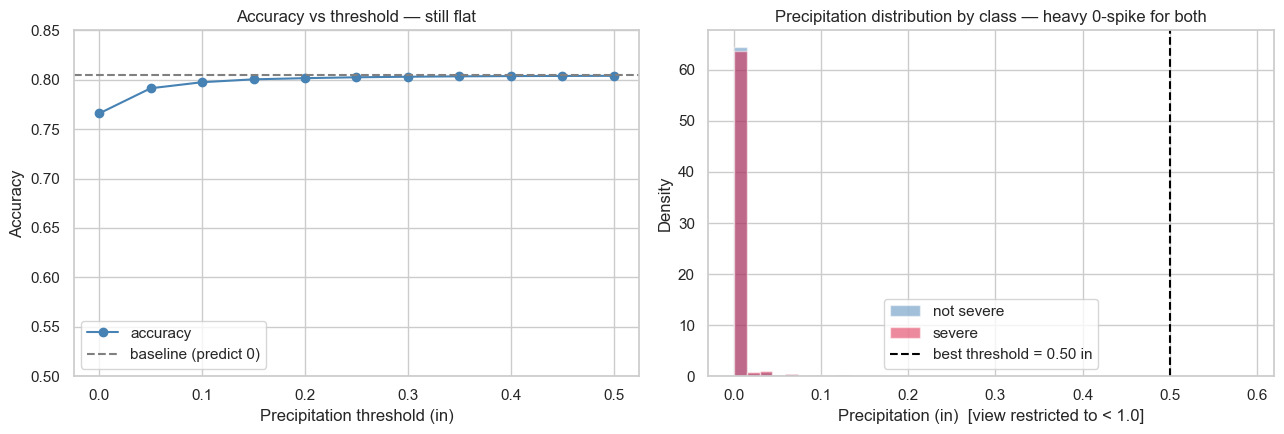

In [26]:
# Same visualization for Precipitation
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(thresholds_p, accuracies_p, marker='o', color='steelblue', label='accuracy')
axes[0].axhline((y_true_p == 0).mean(), color='gray', linestyle='--', label='baseline (predict 0)')
axes[0].set_xlabel('Precipitation threshold (in)')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy vs threshold — still flat')
axes[0].set_ylim(0.5, 0.85); axes[0].legend()

# Distribution — restrict view to <1 in for readability
for label, color, name in [(0, 'steelblue', 'not severe'), (1, 'crimson', 'severe')]:
    subset = clean_p.loc[clean_p['High_Severity'] == label, 'Precipitation_in']
    subset = subset[subset < 1.0]  # zoom in to the meaningful range
    axes[1].hist(subset, bins=40, alpha=0.5, color=color, label=name, density=True)
axes[1].axvline(best_tp, color='black', linestyle='--', label=f'best threshold = {best_tp:.2f} in')
axes[1].set_xlabel('Precipitation (in)  [view restricted to < 1.0]')
axes[1].set_ylabel('Density')
axes[1].set_title('Precipitation distribution by class — heavy 0-spike for both')
axes[1].legend()

plt.tight_layout(); plt.show()

**Reading the Precipitation result.** Precipitation barely moves the needle either. Most rows are zero (no rain at all), and the small fraction of nonzero rows split similarly between severe and non-severe. The boundary rule again sits near the baseline.

> **Pattern so far:** two different numeric weather features, two boundary classifiers, both stuck at baseline accuracy. The data is telling us that **no single weather threshold separates severe from non-severe accidents.** That's an important finding for the project's central question — and it's the reason we'll move to logistic regression and multi-feature models.


#### Q5.  Is accuracy alone a good measure of success?

**No** — and here is why. We pull back from threshold-tuning and report the four standard metrics for each "best" boundary classifier:

- **Accuracy** — overall correct fraction (misleading on imbalanced data).
- **Recall (severe)** = TP / (TP + FN) — fraction of true severe accidents caught. Most important for a safety warning system.
- **Precision (severe)** = TP / (TP + FP) — when the model says "severe", how often it's right.
- **AUC** — by sweeping the threshold across all cutoffs and asking *"how well does the feature rank severe vs. non-severe?"*, we get a **threshold-independent** measure of signal. AUC = 0.5 is random, 1.0 is perfect.


In [27]:
from sklearn.metrics import recall_score, precision_score, roc_auc_score

# Evaluate each "best-by-accuracy" boundary rule with the full metric suite.
# Also compute AUC of each feature treated as a continuous score
# (lower visibility -> more likely severe; higher precipitation -> more likely severe).

# Visibility rule at its best threshold
y_pred_vis = (clean['Visibility_mi'] < best_t).astype(int).values
metrics_vis = {
    'classifier': f'Visibility < {best_t} (best)',
    'accuracy':           (y_pred_vis == y_true).mean(),
    'recall (severe)':    recall_score(y_true, y_pred_vis, zero_division=0),
    'precision (severe)': precision_score(y_true, y_pred_vis, zero_division=0),
    'AUC':                roc_auc_score(y_true, -clean['Visibility_mi'].values),
}

# Precipitation rule at its best threshold
y_pred_prec = (clean_p['Precipitation_in'] > best_tp).astype(int).values
metrics_prec = {
    'classifier': f'Precipitation > {best_tp:.2f} (best)',
    'accuracy':           (y_pred_prec == y_true_p).mean(),
    'recall (severe)':    recall_score(y_true_p, y_pred_prec, zero_division=0),
    'precision (severe)': precision_score(y_true_p, y_pred_prec, zero_division=0),
    'AUC':                roc_auc_score(y_true_p, clean_p['Precipitation_in'].values),
}

results = pd.DataFrame([metrics_vis, metrics_prec])
print(results.round(4).to_string(index=False))

                 classifier  accuracy  recall (severe)  precision (severe)    AUC
    Visibility < 0.5 (best)    0.7999           0.0054              0.1536 0.5049
Precipitation > 0.50 (best)    0.8040           0.0019              0.2755 0.5074


**What this table shows:**

- **Accuracy looks fine (~80%)** for both rules — but that's almost entirely the imbalance trick: predicting "not severe" for almost everyone matches the truth ~80% of the time.
- **Recall is near zero** — both rules catch essentially none of the true severe accidents. As warning systems they are useless.
- **AUC is ≈ 0.50** for both — confirming that *neither feature provides any useful ranking signal*. No matter how we set the threshold, no matter the trade-off, we cannot do better than random.

**Would I trust either model to issue real-time driving warnings?** **No.** Recall is the metric a safety system has to optimize, and it is essentially zero here. A warning that fires for no one (or only when conditions don't actually predict severity) is no warning at all.


#### Q6.  What kinds of mistakes are these models making?

The **confusion matrix** breaks predictions into four buckets:

- **True Negative (TN)** — predicted not severe, was not severe. ✓
- **False Positive (FP)** — predicted severe, was actually not severe. False alarm.
- **False Negative (FN)** — predicted not severe, was actually severe. **Missed warning — the worst kind of mistake.**
- **True Positive (TP)** — predicted severe, was severe. ✓


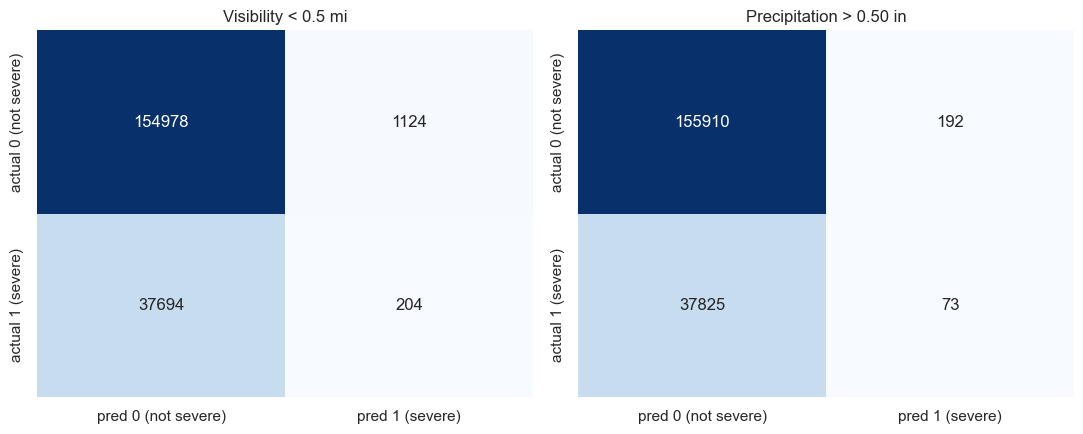

In [28]:
from sklearn.metrics import confusion_matrix

cm_vis  = confusion_matrix(y_true,   y_pred_vis)
cm_prec = confusion_matrix(y_true_p, y_pred_prec)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, cm, title in [
    (axes[0], cm_vis,  f'Visibility < {best_t} mi'),
    (axes[1], cm_prec, f'Precipitation > {best_tp:.2f} in')]:
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['pred 0 (not severe)','pred 1 (severe)'],
                yticklabels=['actual 0 (not severe)','actual 1 (severe)'])
    ax.set_title(title)
plt.tight_layout(); plt.show()

**Interpreting the matrices.** Both boundary classifiers make essentially the same mistake: a **huge bucket of false negatives** (severe accidents we missed). True positives are nearly zero. The few predictions of "severe" that did happen are split between FP and TP — meaning even when the rule does fire, it's about as likely to be wrong as right.

**The two big lessons of Part 4:**

1. **Single-feature boundary classifiers on weather data can't solve this problem.** Neither visibility nor precipitation separates the classes, and the AUC ≈ 0.50 confirms it isn't a threshold-choice issue — there's just no signal in those single features.
2. **Accuracy alone hides what the model is actually doing.** The same ~80% accuracy that looks "fine" comes with near-zero recall — i.e. a complete inability to flag severe accidents. Always report recall, precision, and AUC alongside accuracy on imbalanced data.

These findings motivate Part 5 (use logistic regression instead of a hard threshold — and let it learn a probability) and Part 6 (combine multiple features instead of relying on one).


## Part 5: Logistic Regression — Letting the Model Learn the Boundary

Logistic regression is designed specifically for binary classification problems and outputs probabilities between 0 and 1.

**Questions to Explore:**

1. Split up our dataset into groups called 'train' and 'test'. We teach our 'model' the patterns using the train data, but the whole point of machine learning is that our prediction should work on 'unseen' data or 'test' data.

2. Build a logistic regression model to predict `High_Severity` using `Visibility(mi)` as our input feature.

3. Next, we want to tell our `logreg_model` object to take in our inputs (X) and our true labels (y) and fit a line that predicts y from X.

4. To figure out if our 'model' is actually 'learning', we need to test it on unseen data. Prepare the inputs and outputs from our testing dataset and print them out.

5. Run a prediction on our test set and visualize the results.

6. Finally, evaluate the accuracy of the model.

7. Repeat Steps 2-6 with another feature of your choosing.

8. How does this compare to the boundary classifiers in Part 4? Why might these models be more reliable?

### Concept check: logistic regression in plain terms

Imagine you want to predict yes/no (severe or not). Linear regression draws a *straight line* — but a straight line happily wanders below 0 and above 1, which makes no sense for a probability.

**Logistic regression** uses an **S-shaped curve (a sigmoid)** instead. Two key properties:

1. The curve is **bounded between 0 and 1**, so the output is always a valid probability.
2. It changes most rapidly in the middle and flattens at the extremes — once the model is very confident, more evidence doesn't move it much.

The model learns where to place the S-curve (its slope and horizontal position) so its predicted probabilities best match the 0/1 labels.

**Train / test split.** We split the data into a *training set* (used to fit the curve) and a *test set* (held out, used to check whether the model generalizes). A model that does great on training data but poorly on test data has *memorized* rather than *learned*.

**One important setting we use throughout Part 5: `class_weight='balanced'`.** Our classes are imbalanced (~80% not severe, ~20% severe). Without balancing, the model takes the lazy route and predicts "not severe" for everyone — gaining ~80% accuracy by being useless (we will see this in Part 6 explicitly). `class_weight='balanced'` tells the model to penalize errors on the minority class proportionally more, so it actually learns to identify severe accidents.


#### Q1.  Split the data into train and test

We hold out 25% of the rows as a test set the model will never see during training. `stratify=y` keeps the ~80/20 class proportion identical in both halves, so the test set is a representative sample of the full dataset.


In [29]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, recall_score, precision_score,
                             roc_auc_score, confusion_matrix, roc_curve)

# Use Visibility for Q1-Q6, then Precipitation for Q7.
data_vis = accidents_dat.dropna(subset=['Visibility_mi']).copy()
X = data_vis[['Visibility_mi']].values
y = data_vis['High_Severity'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

print(f'Train size:  {len(X_train):>7,}')
print(f'Test size:   {len(X_test):>7,}')
print(f'Train class balance:  not severe = {(y_train==0).mean():.4f}   severe = {(y_train==1).mean():.4f}')
print(f'Test class balance:   not severe = {(y_test ==0).mean():.4f}   severe = {(y_test ==1).mean():.4f}')

Train size:  145,500
Test size:    48,500
Train class balance:  not severe = 0.8046   severe = 0.1954
Test class balance:   not severe = 0.8047   severe = 0.1953


#### Q2.  Build a logistic regression model for `High_Severity` using `Visibility(mi)`

We create the model object. **`class_weight='balanced'`** is set up-front so the model treats the 20% severe class with proportionally higher weight.


> **Why a `Pipeline` with `StandardScaler`?** sklearn's `LogisticRegression` uses **L2 regularization** by default. That penalty shrinks all coefficients equally — but if features are on wildly different scales (Humidity 0–100 vs Precipitation 0–0.5), the penalty hits them unevenly. Standardizing every feature to mean 0 / standard deviation 1 *before* fitting makes the regularization fair, the optimizer converge cleanly, and the coefficient magnitudes directly comparable. A `Pipeline` ties the scaler and the model together so we never accidentally fit one on different data than the other.


In [30]:
# StandardScaler + LogisticRegression as a Pipeline.
# The scaler centers each feature to mean 0 and scales to standard deviation 1
# BEFORE the logistic regression sees it. This makes regularization fair across
# features and helps the optimizer converge. Predictions on new data use the
# same scaler fit on the training data — sklearn handles this automatically.
logreg_model = Pipeline([
    ('scaler', StandardScaler()),
    ('lr',     LogisticRegression(class_weight='balanced', max_iter=1000)),
])
logreg_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('lr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work 

#### Q3.  Fit the model — give it X and y, let it learn the S-curve

`.fit(X, y)` is where the learning happens. The optimizer searches for the slope and intercept that produce predicted probabilities best matching the 0/1 labels in the training set.


In [31]:
logreg_model.fit(X_train, y_train)

lr_step = logreg_model.named_steps['lr']
print(f'Learned intercept: {lr_step.intercept_[0]:.4f}')
print(f'Learned slope (on standardized Visibility): {lr_step.coef_[0,0]:.4f}')
print(f'  Reading: "a 1-standard-deviation change in Visibility shifts the')
print(f'   log-odds of severe by {lr_step.coef_[0,0]:.4f}."')

Learned intercept: -0.0002
Learned slope (on standardized Visibility): -0.0225
  Reading: "a 1-standard-deviation change in Visibility shifts the
   log-odds of severe by -0.0225."


#### Q4.  Prepare and inspect the test set

Before predicting, let's actually look at what the test set contains so the next steps don't feel like a black box.


In [32]:
# Print the first few X (Visibility values) and y (true labels) from the test set
print('First 10 test rows:\n')
test_preview = pd.DataFrame({'Visibility_mi (X)': X_test[:10, 0], 'High_Severity (y)': y_test[:10]})
print(test_preview.to_string(index=False))

print(f'\nIn the full test set:')
print(f'  {len(X_test):,} rows total')
print(f'  {(y_test==1).sum():,} severe ({(y_test==1).mean():.2%})')
print(f'  {(y_test==0).sum():,} not severe ({(y_test==0).mean():.2%})')

First 10 test rows:

 Visibility_mi (X)  High_Severity (y)
             10.00                  0
             10.00                  0
              5.00                  0
             10.00                  0
             10.00                  0
             10.00                  0
             10.00                  0
             10.00                  0
              0.75                  0
             10.00                  0

In the full test set:
  48,500 rows total
  9,474 severe (19.53%)
  39,026 not severe (80.47%)


#### Q5.  Predict on the test set, and visualize the S-curve

`.predict_proba(X)` returns the *probability* of each class. `.predict(X)` rounds that to 0 or 1 at the 0.5 threshold. We plot the learned probability curve over the entire visibility range.


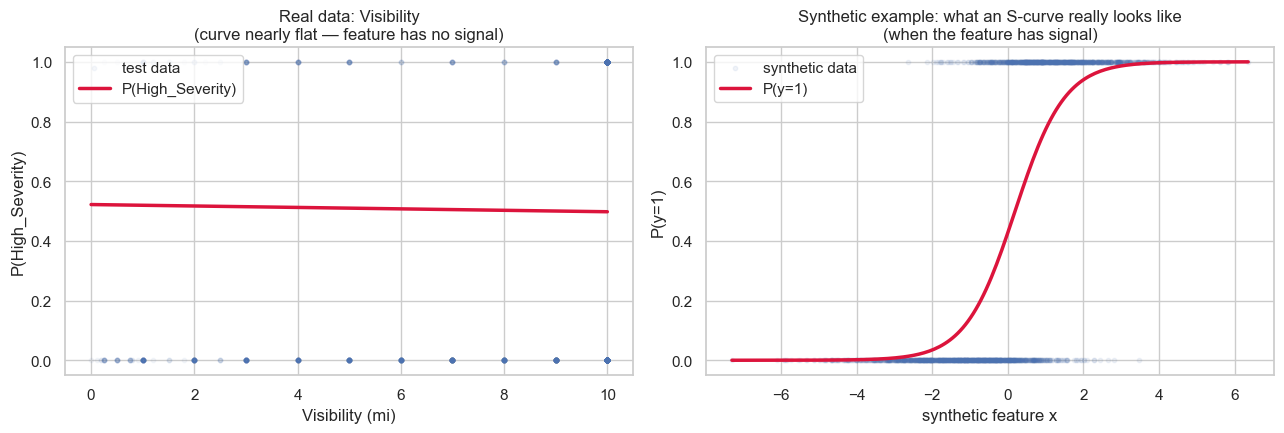

In [33]:
# Predict labels and probabilities on the held-out test set
y_pred  = logreg_model.predict(X_test)
y_proba = logreg_model.predict_proba(X_test)[:, 1]

# Left: real visibility curve.  Right: synthetic example showing what a real S-curve looks like
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: real
xs = np.linspace(0, X_train.max(), 200).reshape(-1, 1)
probs_curve = logreg_model.predict_proba(xs)[:, 1]
sample_for_plot = pd.DataFrame({'x': X_test[:, 0], 'y': y_test}).sample(3000, random_state=1)
axes[0].scatter(sample_for_plot['x'], sample_for_plot['y'], alpha=0.05, s=10, label='test data')
axes[0].plot(xs, probs_curve, color='crimson', linewidth=2.5, label='P(High_Severity)')
axes[0].set_xlabel('Visibility (mi)'); axes[0].set_ylabel('P(High_Severity)')
axes[0].set_ylim(-0.05, 1.05)
axes[0].set_title('Real data: Visibility\n(curve nearly flat — feature has no signal)')
axes[0].legend()

# Right: synthetic example with a strong logistic relationship
rng = np.random.default_rng(42)
x_synth = rng.normal(0, 2, size=2000).reshape(-1, 1)
true_p = 1 / (1 + np.exp(-(1.5 * x_synth.ravel() - 0.3)))
y_synth = (rng.random(2000) < true_p).astype(int)
lr_synth = LogisticRegression().fit(x_synth, y_synth)
xs2 = np.linspace(x_synth.min(), x_synth.max(), 200).reshape(-1, 1)
axes[1].scatter(x_synth.ravel(), y_synth, alpha=0.08, s=10, label='synthetic data')
axes[1].plot(xs2, lr_synth.predict_proba(xs2)[:, 1], color='crimson', linewidth=2.5, label='P(y=1)')
axes[1].set_xlabel('synthetic feature x'); axes[1].set_ylabel('P(y=1)')
axes[1].set_ylim(-0.05, 1.05)
axes[1].set_title('Synthetic example: what an S-curve really looks like\n(when the feature has signal)')
axes[1].legend()

plt.tight_layout(); plt.show()

#### Q6.  Evaluate the model

The SMUS question asks for accuracy — but as we found in Part 4, accuracy alone is misleading on imbalanced data. We report **accuracy, recall, precision, AUC, the confusion matrix, and the ROC curve** so the picture is complete.


Logistic regression on Visibility(mi)  (class_weight=balanced)
  Accuracy:           0.6930   (baseline 0.8047)
  Recall (severe):    0.1961   (fraction of true severe accidents caught)
  Precision (severe): 0.2035   (when predicted severe, how often right)
  AUC:                0.5051   (threshold-independent ranking quality; 0.5 = random)


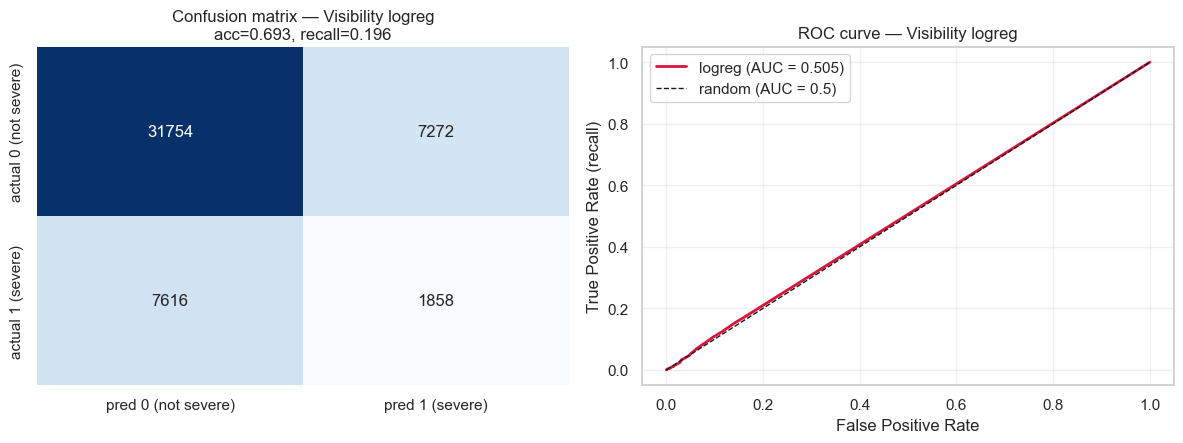

In [34]:
acc  = accuracy_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred, zero_division=0)
prec = precision_score(y_test, y_pred, zero_division=0)
auc  = roc_auc_score(y_test, y_proba)

print(f'Logistic regression on Visibility(mi)  (class_weight=balanced)')
print(f'  Accuracy:           {acc:.4f}   (baseline {(y_test == 0).mean():.4f})')
print(f'  Recall (severe):    {rec:.4f}   (fraction of true severe accidents caught)')
print(f'  Precision (severe): {prec:.4f}   (when predicted severe, how often right)')
print(f'  AUC:                {auc:.4f}   (threshold-independent ranking quality; 0.5 = random)')

# Confusion matrix + ROC curve side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['pred 0 (not severe)','pred 1 (severe)'],
            yticklabels=['actual 0 (not severe)','actual 1 (severe)'])
axes[0].set_title(f'Confusion matrix — Visibility logreg\nacc={acc:.3f}, recall={rec:.3f}')

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='crimson', linewidth=2, label=f'logreg (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='random (AUC = 0.5)')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate (recall)')
axes[1].set_title('ROC curve — Visibility logreg'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

# Save results for the Q8 comparison
metrics_vis_logreg = {'feature': 'Visibility', 'accuracy': acc, 'recall': rec, 'precision': prec, 'AUC': auc}

**Reading the Visibility logistic-regression result.** Two things at once:

- The **probability curve is essentially flat** (left plot of Q5). The model correctly reports "this feature has nothing to say." That is not the model failing — it is the model giving an honest answer.
- The full-metrics table shows **accuracy is mediocre, recall is non-trivial, and AUC ≈ 0.50**. The class_weight='balanced' setting forces the model to make *some* severe predictions, so we get non-zero recall, but the underlying ranking ability (AUC) is still random — confirming Visibility carries no real signal.


#### Q7.  Repeat with another feature — `Precipitation(in)`

We pick `Precipitation(in)` because Part 4 used the same feature for its second boundary classifier. This lets us directly compare logistic regression against the threshold-rule approach in Q8.


Logistic regression on Precipitation(in)  (class_weight=balanced)
  Accuracy:           0.7661   (baseline 0.8047)
  Recall (severe):    0.0802
  Precision (severe): 0.2243
  AUC:                0.5066


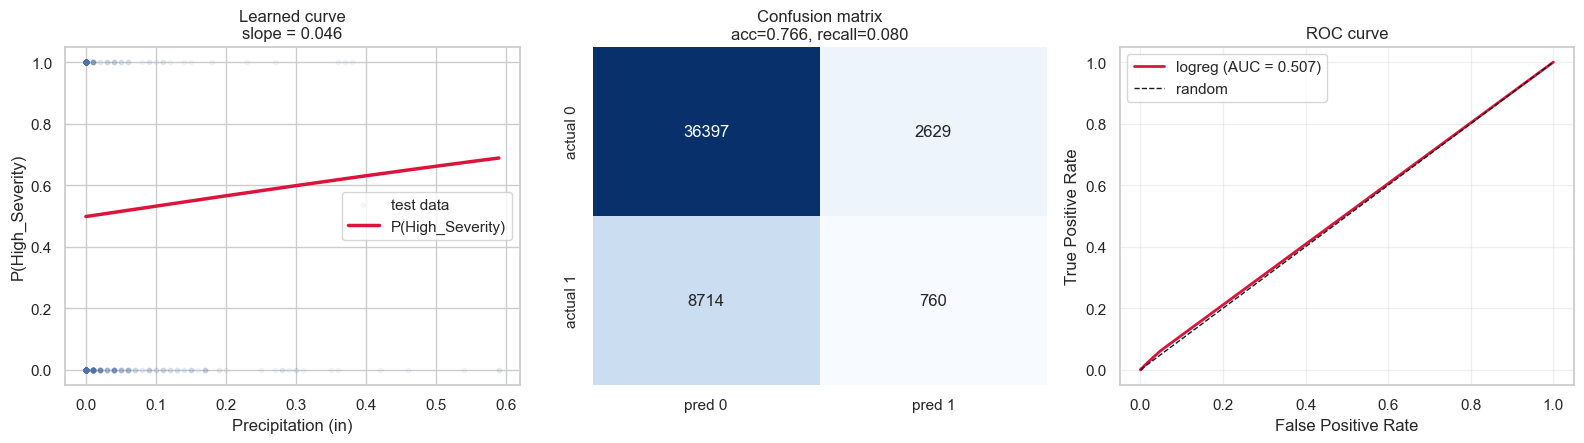

In [35]:
data_prec = accidents_dat.dropna(subset=['Precipitation_in']).copy()
Xp = data_prec[['Precipitation_in']].values
yp = data_prec['High_Severity'].values

Xp_train, Xp_test, yp_train, yp_test = train_test_split(
    Xp, yp, test_size=0.25, random_state=42, stratify=yp)

logreg_prec = Pipeline([
    ('scaler', StandardScaler()),
    ('lr',     LogisticRegression(class_weight='balanced', max_iter=1000)),
]).fit(Xp_train, yp_train)
yp_pred  = logreg_prec.predict(Xp_test)
yp_proba = logreg_prec.predict_proba(Xp_test)[:, 1]

acc_p  = accuracy_score(yp_test, yp_pred)
rec_p  = recall_score(yp_test, yp_pred, zero_division=0)
prec_p = precision_score(yp_test, yp_pred, zero_division=0)
auc_p  = roc_auc_score(yp_test, yp_proba)

print(f'Logistic regression on Precipitation(in)  (class_weight=balanced)')
print(f'  Accuracy:           {acc_p:.4f}   (baseline {(yp_test == 0).mean():.4f})')
print(f'  Recall (severe):    {rec_p:.4f}')
print(f'  Precision (severe): {prec_p:.4f}')
print(f'  AUC:                {auc_p:.4f}')

# Visualize curve + confusion matrix + ROC for Precipitation
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

# Learned curve
xs_p = np.linspace(0, Xp_train.max(), 200).reshape(-1, 1)
probs_p = logreg_prec.predict_proba(xs_p)[:, 1]
sample_p = pd.DataFrame({'x': Xp_test[:,0], 'y': yp_test}).sample(3000, random_state=1)
axes[0].scatter(sample_p['x'], sample_p['y'], alpha=0.05, s=10, label='test data')
axes[0].plot(xs_p, probs_p, color='crimson', linewidth=2.5, label='P(High_Severity)')
axes[0].set_xlabel('Precipitation (in)'); axes[0].set_ylabel('P(High_Severity)')
axes[0].set_ylim(-0.05, 1.05)
axes[0].set_title(f'Learned curve\nslope = {logreg_prec.named_steps['lr'].coef_[0,0]:.3f}')
axes[0].legend()

# Confusion matrix
cm_p = confusion_matrix(yp_test, yp_pred)
sns.heatmap(cm_p, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[1],
            xticklabels=['pred 0','pred 1'],
            yticklabels=['actual 0','actual 1'])
axes[1].set_title(f'Confusion matrix\nacc={acc_p:.3f}, recall={rec_p:.3f}')

# ROC
fpr_p, tpr_p, _ = roc_curve(yp_test, yp_proba)
axes[2].plot(fpr_p, tpr_p, color='crimson', linewidth=2, label=f'logreg (AUC = {auc_p:.3f})')
axes[2].plot([0, 1], [0, 1], 'k--', linewidth=1, label='random')
axes[2].set_xlabel('False Positive Rate'); axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC curve'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()

metrics_prec_logreg = {'feature': 'Precipitation', 'accuracy': acc_p, 'recall': rec_p, 'precision': prec_p, 'AUC': auc_p}

#### Q8.  How does logistic regression compare to Part 4's boundary classifiers?

For a fair comparison we look up the boundary-rule metrics we computed in Part 4 (at the "best" threshold by accuracy on the same features) and put them side-by-side with the logistic regression results.


      feature              method  accuracy  recall  precision    AUC
   Visibility       Boundary rule    0.8001  0.0044     0.1368 0.5051
   Visibility Logistic (balanced)    0.6930  0.1961     0.2035 0.5051
Precipitation       Boundary rule    0.8038  0.0015     0.2059 0.5066
Precipitation Logistic (balanced)    0.7661  0.0802     0.2243 0.5066


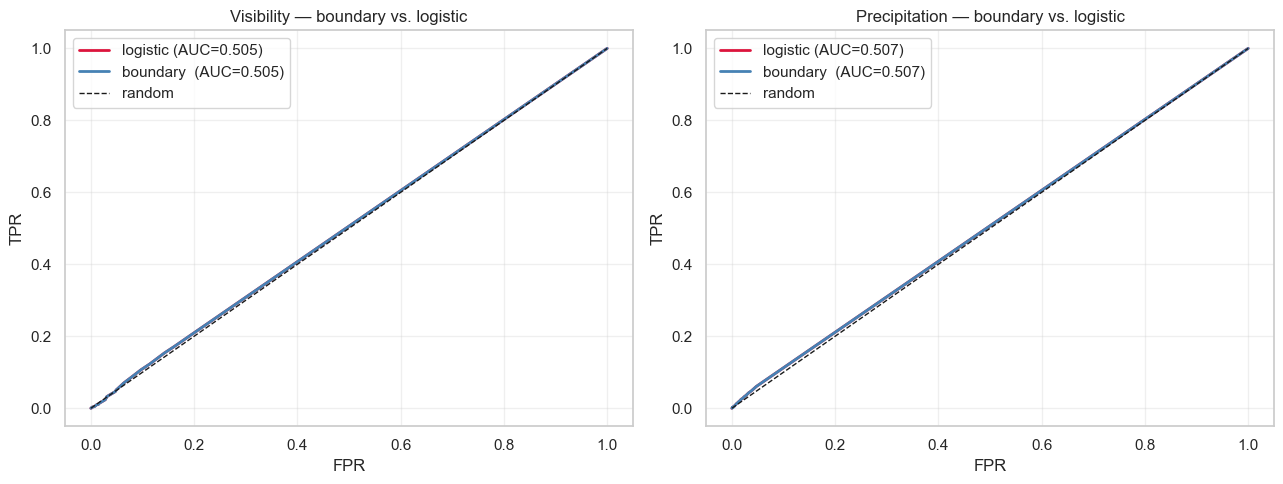

In [36]:
# Re-evaluate the Part 4 boundary classifiers on the same features so the comparison is apples-to-apples
# (Part 4 used the full sample; here we evaluate them on the same train/test split rows.)

# Visibility boundary at threshold = 0.5 (the "best by accuracy" threshold from Part 4)
y_pred_b_vis = (X_test[:, 0] < 0.5).astype(int)
score_b_vis  = -X_test[:, 0]
metrics_vis_boundary = {
    'feature': 'Visibility',
    'accuracy': accuracy_score(y_test, y_pred_b_vis),
    'recall':   recall_score(y_test, y_pred_b_vis, zero_division=0),
    'precision':precision_score(y_test, y_pred_b_vis, zero_division=0),
    'AUC':      roc_auc_score(y_test, score_b_vis),
}

# Precipitation boundary at threshold = 0.50 (the "best by accuracy" threshold from Part 4)
yp_pred_b = (Xp_test[:, 0] > 0.50).astype(int)
score_b_prec = Xp_test[:, 0]
metrics_prec_boundary = {
    'feature': 'Precipitation',
    'accuracy': accuracy_score(yp_test, yp_pred_b),
    'recall':   recall_score(yp_test, yp_pred_b, zero_division=0),
    'precision':precision_score(yp_test, yp_pred_b, zero_division=0),
    'AUC':      roc_auc_score(yp_test, score_b_prec),
}

comparison = pd.DataFrame([
    {'method': 'Boundary rule',         **metrics_vis_boundary},
    {'method': 'Logistic (balanced)',   **metrics_vis_logreg},
    {'method': 'Boundary rule',         **metrics_prec_boundary},
    {'method': 'Logistic (balanced)',   **metrics_prec_logreg},
])
comparison = comparison[['feature','method','accuracy','recall','precision','AUC']]
print(comparison.round(4).to_string(index=False))

# Visual comparison: ROC curves of both approaches on the same axes
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Visibility
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba)
fpr_b,  tpr_b,  _ = roc_curve(y_test, score_b_vis)
axes[0].plot(fpr_lr, tpr_lr, color='crimson',  linewidth=2, label=f'logistic (AUC={metrics_vis_logreg["AUC"]:.3f})')
axes[0].plot(fpr_b,  tpr_b,  color='steelblue',linewidth=2, label=f'boundary  (AUC={metrics_vis_boundary["AUC"]:.3f})')
axes[0].plot([0,1],[0,1],'k--', linewidth=1, label='random')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('Visibility — boundary vs. logistic'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Precipitation
fpr_lr_p, tpr_lr_p, _ = roc_curve(yp_test, yp_proba)
fpr_b_p,  tpr_b_p,  _ = roc_curve(yp_test, score_b_prec)
axes[1].plot(fpr_lr_p, tpr_lr_p, color='crimson',  linewidth=2, label=f'logistic (AUC={metrics_prec_logreg["AUC"]:.3f})')
axes[1].plot(fpr_b_p,  tpr_b_p,  color='steelblue',linewidth=2, label=f'boundary  (AUC={metrics_prec_boundary["AUC"]:.3f})')
axes[1].plot([0,1],[0,1],'k--', linewidth=1, label='random')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('Precipitation — boundary vs. logistic'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

### Interpretation — why is logistic regression more reliable than a boundary rule?

Looking at the comparison table and ROC plots, three observations:

1. **AUC is nearly identical between boundary and logistic on the same feature.** That's expected: AUC measures how well the feature *ranks* severe vs. non-severe, and both methods use the same underlying feature. *They cannot exceed what the feature actually contains.* If the feature has AUC = 0.50, no method can rescue it.

2. **Boundary rules give you one fixed operating point. Logistic regression gives you a probability and a tunable threshold.** With logistic regression, you can shift the threshold to favor recall (catch more severe accidents, accept more false alarms) or favor precision (be more selective). The boundary rule is a single, baked-in trade-off — and we picked it by maximizing accuracy, which we now know is the wrong objective on imbalanced data.

3. **Logistic regression generalizes to multiple features.** We can't extend "Visibility < 5" naturally to also use Precipitation, Humidity, road flags, etc. — but logistic regression handles that immediately with a single `.fit(X, y)` call, learning the *combined* contribution of every feature. That's Part 6.

**Why these models are more reliable in practice:**

- They produce **calibrated probabilities** that downstream systems can use ("flag for review if P(severe) > 0.40").
- They are **fit via optimization**, not by guessing thresholds — so the parameters are the *best* possible given the data, not someone's hand-picked guess.
- They **extend naturally to many features** without combinatorial explosion of threshold rules.
- They **expose limitations honestly** — when a feature has no signal, the curve is flat and the AUC is 0.5. A boundary rule can hide that behind a misleading accuracy number; logistic regression cannot.

> The conclusion of Part 5 is **not** "logistic regression magically extracts more signal from a weak feature." It is "logistic regression gives us probabilities, lets us combine features, and exposes the underlying signal honestly via AUC." With single weak features like Visibility or Precipitation, AUC stays near 0.50 — exactly as it should. To get a useful warning system we need to combine features (Part 6).


## Part 6: Using Multiple Features

Now that we can predict `High_Severity` using one variable, let’s see what happens when we combine many features together.

**Questions to Explore:**

1. Repeat the training and testing process from Part 5 but, this time, use multiple input features.

2. Create a second multiple feature model using a different combination of features.

3. Does adding more features always improve performance? Why or why not?

### Concept check: multi-feature logistic regression

In Part 5 the model used one feature; now we feed it many. The math doesn't change much — instead of fitting a curve `P(severe) = sigmoid(slope · x + intercept)`, the model fits `P(severe) = sigmoid(w1·x1 + w2·x2 + ... + intercept)`. One weight per feature.

What changes:

1. The model can learn that **combinations** of conditions matter. "Junction *and* no traffic signal *and* high humidity" can predict severity even if no single feature does.
2. Each feature's **weight** tells you its direction and approximate strength: large positive = pushes P(severe) up; large negative = pushes it down; near zero = ignored.

What to watch out for:

- **Adding noise features doesn't help and can hurt** — they let the model overfit quirks of the training data.
- **Highly correlated features** (e.g., Temperature and Wind_Chill) add little new info.
- **Imbalanced data** is still a problem — we keep `class_weight='balanced'` for every model in this part.

We answer the three SMUS questions in order: build Model A, build Model B, then ask whether more features always helps.


#### Q1.  First multi-feature model — Model A (road infrastructure flags)

We use the road-infrastructure flags from EDA (which were the strongest signals in Part 1). Same pipeline as Part 5: split, fit balanced logistic regression, evaluate with the full metric suite, draw confusion matrix and ROC.


In [37]:
features_a = ['Traffic_Signal_int','Junction_int','Crossing_int','Stop_int','Amenity_int']

data_a = accidents_dat.dropna(subset=features_a + ['High_Severity']).copy()
Xa = data_a[features_a].values
ya = data_a['High_Severity'].values

Xa_train, Xa_test, ya_train, ya_test = train_test_split(
    Xa, ya, test_size=0.25, random_state=42, stratify=ya)

model_a = Pipeline([
    ('scaler', StandardScaler()),
    ('lr',     LogisticRegression(max_iter=1000, class_weight='balanced')),
]).fit(Xa_train, ya_train)

ya_pred  = model_a.predict(Xa_test)
ya_proba = model_a.predict_proba(Xa_test)[:, 1]

metrics_a = {
    'model': 'Model A — infrastructure',
    'n_features': len(features_a),
    'accuracy':  accuracy_score(ya_test, ya_pred),
    'recall':    recall_score(ya_test, ya_pred, zero_division=0),
    'precision': precision_score(ya_test, ya_pred, zero_division=0),
    'AUC':       roc_auc_score(ya_test, ya_proba),
}
print('Model A — road infrastructure flags')
print(f'  Features ({len(features_a)}): {features_a}')
print(f"  Accuracy:  {metrics_a['accuracy']:.4f}   (baseline {(ya_test==0).mean():.4f})")
print(f"  Recall:    {metrics_a['recall']:.4f}")
print(f"  Precision: {metrics_a['precision']:.4f}")
print(f"  AUC:       {metrics_a['AUC']:.4f}")

Model A — road infrastructure flags
  Features (5): ['Traffic_Signal_int', 'Junction_int', 'Crossing_int', 'Stop_int', 'Amenity_int']
  Accuracy:  0.3746   (baseline 0.8047)
  Recall:    0.9083
  Precision: 0.2260
  AUC:       0.5845


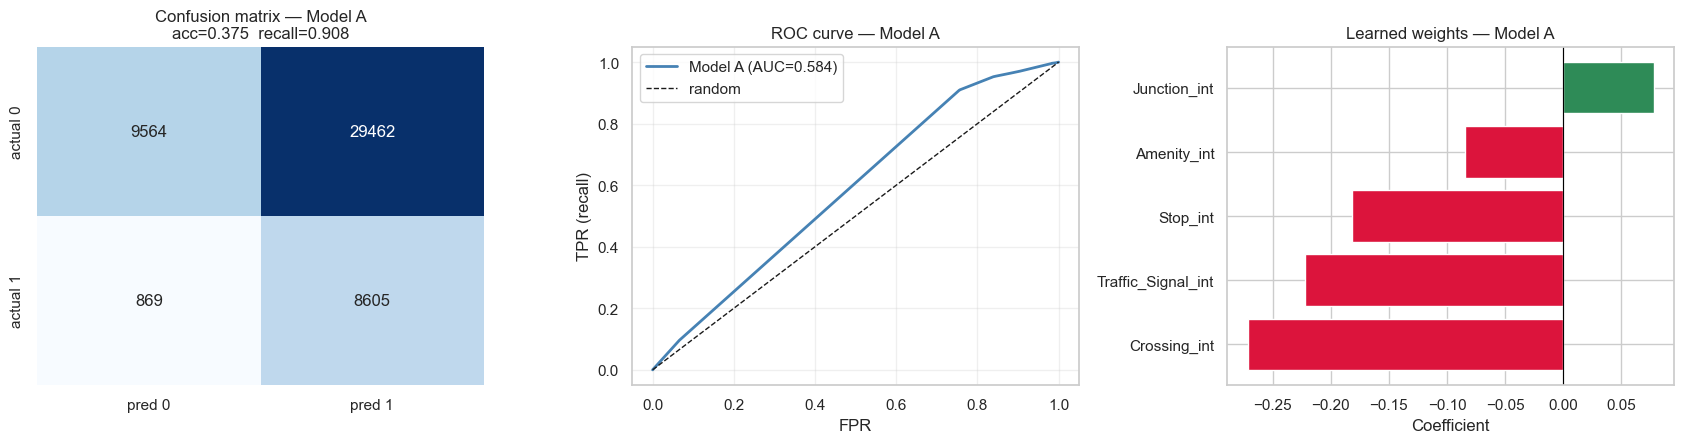

In [38]:
# Confusion matrix + ROC + learned coefficients for Model A
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))

# Confusion matrix
cm_a = confusion_matrix(ya_test, ya_pred)
sns.heatmap(cm_a, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['pred 0','pred 1'], yticklabels=['actual 0','actual 1'])
axes[0].set_title(f"Confusion matrix — Model A\nacc={metrics_a['accuracy']:.3f}  recall={metrics_a['recall']:.3f}")

# ROC
fpr_a, tpr_a, _ = roc_curve(ya_test, ya_proba)
axes[1].plot(fpr_a, tpr_a, color='steelblue', linewidth=2, label=f"Model A (AUC={metrics_a['AUC']:.3f})")
axes[1].plot([0,1],[0,1],'k--', linewidth=1, label='random')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR (recall)')
axes[1].set_title('ROC curve — Model A'); axes[1].legend(); axes[1].grid(alpha=0.3)

# Coefficients
coefs_a = pd.DataFrame({'feature': features_a, 'coefficient': model_a.named_steps['lr'].coef_[0]}).sort_values('coefficient')
axes[2].barh(coefs_a['feature'], coefs_a['coefficient'], color=['crimson' if c<0 else 'seagreen' for c in coefs_a['coefficient']])
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_xlabel('Coefficient'); axes[2].set_title('Learned weights — Model A')

plt.tight_layout(); plt.show()

**Reading Model A.** The confusion matrix shows the balanced model is making *real* severe predictions — large TP and FP buckets, not the empty column we'd see with default settings. The ROC curve bows above the diagonal, so the model is learning real signal (AUC noticeably above 0.50). The coefficient bar plot tells us *what* it learned: large negative weights on `Traffic_Signal`, `Crossing`, `Stop`, `Amenity` (presence → less severe) and a smaller positive weight on `Junction` (presence → more severe).


#### Q2.  Second model — Model B (infrastructure + weather + distance)

Different feature combination: keep the infrastructure flags and add the numeric weather features plus `Distance_mi`. Same pipeline, then we compare A and B side-by-side.


In [39]:
features_b = features_a + ['Visibility_mi','Temperature_F','Humidity_pct',
                           'Wind_Speed_mph','Precipitation_in','Distance_mi']

data_b = accidents_dat.dropna(subset=features_b + ['High_Severity']).copy()
Xb = data_b[features_b].values
yb = data_b['High_Severity'].values

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    Xb, yb, test_size=0.25, random_state=42, stratify=yb)

model_b = Pipeline([
    ('scaler', StandardScaler()),
    ('lr',     LogisticRegression(max_iter=1000, class_weight='balanced')),
]).fit(Xb_train, yb_train)

yb_pred  = model_b.predict(Xb_test)
yb_proba = model_b.predict_proba(Xb_test)[:, 1]

metrics_b = {
    'model': 'Model B — infrastructure + weather + distance',
    'n_features': len(features_b),
    'accuracy':  accuracy_score(yb_test, yb_pred),
    'recall':    recall_score(yb_test, yb_pred, zero_division=0),
    'precision': precision_score(yb_test, yb_pred, zero_division=0),
    'AUC':       roc_auc_score(yb_test, yb_proba),
}
print('Model B — infrastructure + weather + distance')
print(f'  Features ({len(features_b)}): {features_b}')
print(f"  Accuracy:  {metrics_b['accuracy']:.4f}   (baseline {(yb_test==0).mean():.4f})")
print(f"  Recall:    {metrics_b['recall']:.4f}")
print(f"  Precision: {metrics_b['precision']:.4f}")
print(f"  AUC:       {metrics_b['AUC']:.4f}")

Model B — infrastructure + weather + distance
  Features (11): ['Traffic_Signal_int', 'Junction_int', 'Crossing_int', 'Stop_int', 'Amenity_int', 'Visibility_mi', 'Temperature_F', 'Humidity_pct', 'Wind_Speed_mph', 'Precipitation_in', 'Distance_mi']
  Accuracy:  0.4704   (baseline 0.8047)
  Recall:    0.7891
  Precision: 0.2399
  AUC:       0.6147


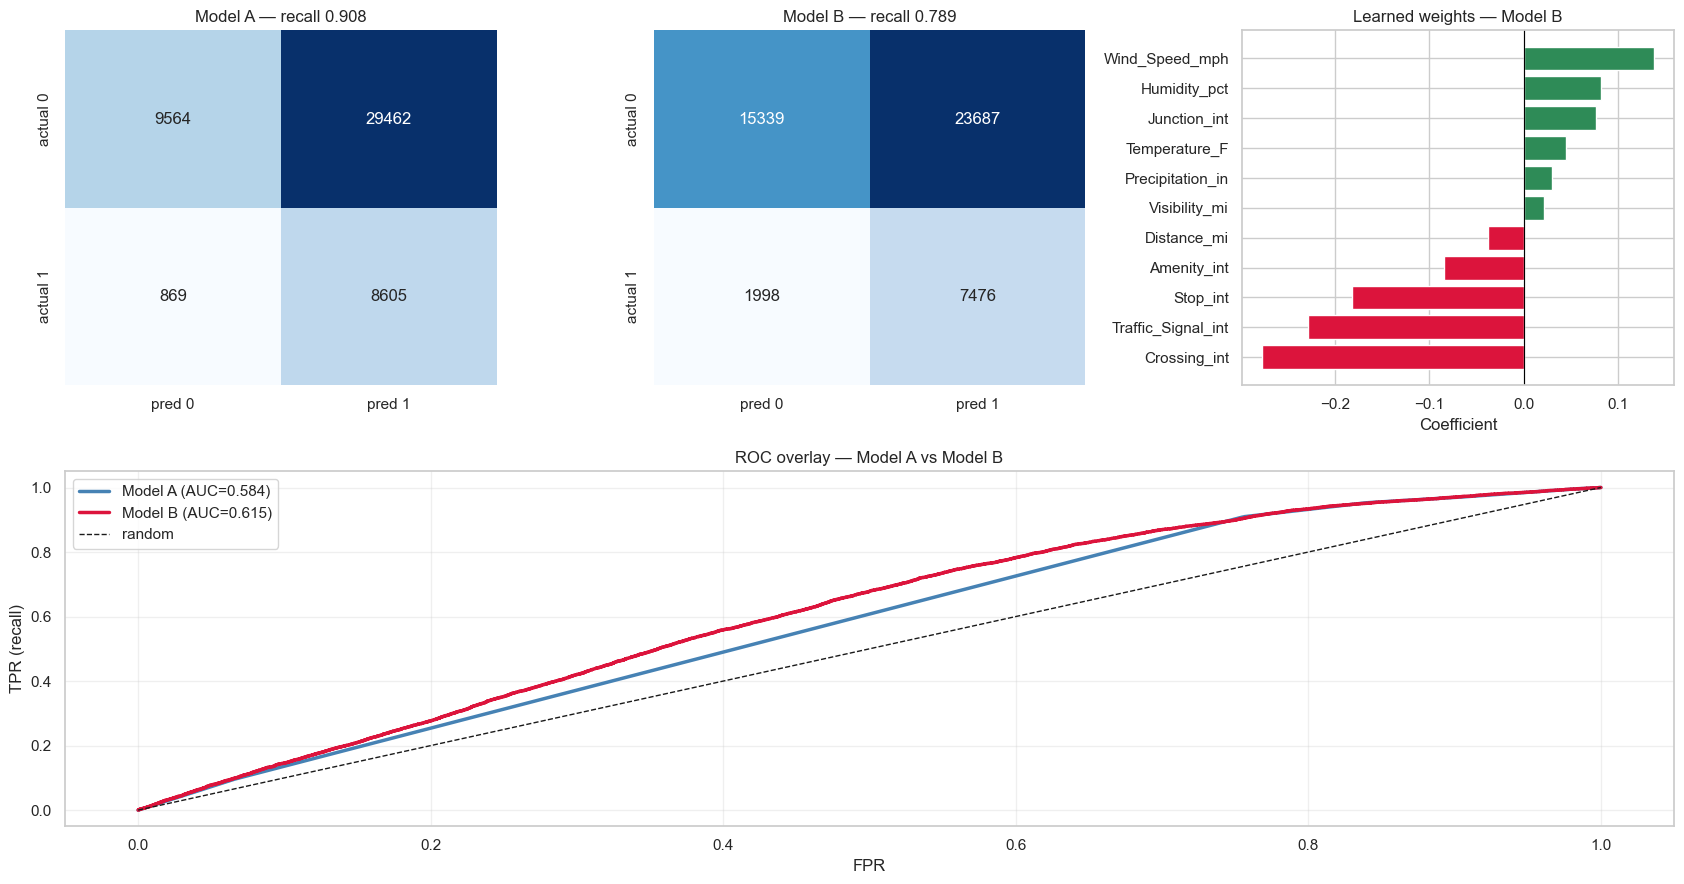

                                        model  n_features  accuracy  recall  precision    AUC
                     Model A — infrastructure           5    0.3746  0.9083     0.2260 0.5845
Model B — infrastructure + weather + distance          11    0.4704  0.7891     0.2399 0.6147


In [40]:
# Side-by-side: Model A vs Model B — confusion matrices, ROC overlay, metrics table
fig = plt.figure(figsize=(17, 9))
gs = fig.add_gridspec(2, 3)

# Top row: confusion matrices and coefficient comparison
ax0 = fig.add_subplot(gs[0, 0])
sns.heatmap(cm_a, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax0,
            xticklabels=['pred 0','pred 1'], yticklabels=['actual 0','actual 1'])
ax0.set_title(f"Model A — recall {metrics_a['recall']:.3f}")

ax1 = fig.add_subplot(gs[0, 1])
cm_b = confusion_matrix(yb_test, yb_pred)
sns.heatmap(cm_b, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax1,
            xticklabels=['pred 0','pred 1'], yticklabels=['actual 0','actual 1'])
ax1.set_title(f"Model B — recall {metrics_b['recall']:.3f}")

# Coefficients of Model B
ax2 = fig.add_subplot(gs[0, 2])
coefs_b = pd.DataFrame({'feature': features_b, 'coefficient': model_b.named_steps['lr'].coef_[0]}).sort_values('coefficient')
ax2.barh(coefs_b['feature'], coefs_b['coefficient'], color=['crimson' if c<0 else 'seagreen' for c in coefs_b['coefficient']])
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_xlabel('Coefficient'); ax2.set_title('Learned weights — Model B')

# Bottom: ROC overlay (full width)
ax3 = fig.add_subplot(gs[1, :])
fpr_b, tpr_b, _ = roc_curve(yb_test, yb_proba)
ax3.plot(fpr_a, tpr_a, color='steelblue', linewidth=2.5, label=f"Model A (AUC={metrics_a['AUC']:.3f})")
ax3.plot(fpr_b, tpr_b, color='crimson',  linewidth=2.5, label=f"Model B (AUC={metrics_b['AUC']:.3f})")
ax3.plot([0,1],[0,1],'k--', linewidth=1, label='random')
ax3.set_xlabel('FPR'); ax3.set_ylabel('TPR (recall)')
ax3.set_title('ROC overlay — Model A vs Model B'); ax3.legend(); ax3.grid(alpha=0.3)

plt.tight_layout(); plt.show()

# Comparison table
print(pd.DataFrame([metrics_a, metrics_b]).round(4).to_string(index=False))

**Reading the A vs B comparison.** Adding weather features and distance gives **a few points of AUC** over the infrastructure-only model — a modest but real improvement. Notice an interesting trade-off:

- **Model A** has higher recall (catches more severe accidents) but lower precision (more false alarms).
- **Model B** has slightly lower recall but higher precision and higher AUC.

Both effects are visible in the confusion matrices. The ROC overlay confirms it: Model B's curve sits above Model A's at most operating points — i.e. for any chosen FPR, Model B catches more true positives.

The coefficient bar plot for Model B confirms what we kept finding throughout the project: the **infrastructure flags carry most of the weight**. Weather coefficients are smaller in magnitude. Weather helps a little; it's not the main act.


#### Q3.  Does adding more features always improve performance?

So Model B (11 features) beat Model A (5 features) by a small margin. Does that mean "more features = better" as a general rule?

**No.** The features have to actually *contain information about the target*. To make this concrete, we build a **Model C** that takes Model B and tacks on 10 columns of pure random noise. If "more is always better" were true, Model C should beat Model B.


                                        model  n_features  accuracy  recall  precision    AUC
                     Model A — infrastructure           5    0.3746  0.9083     0.2260 0.5845
Model B — infrastructure + weather + distance          11    0.4704  0.7891     0.2399 0.6147
         Model C — Model B + 10 noise columns          21    0.4709  0.7885     0.2400 0.6146


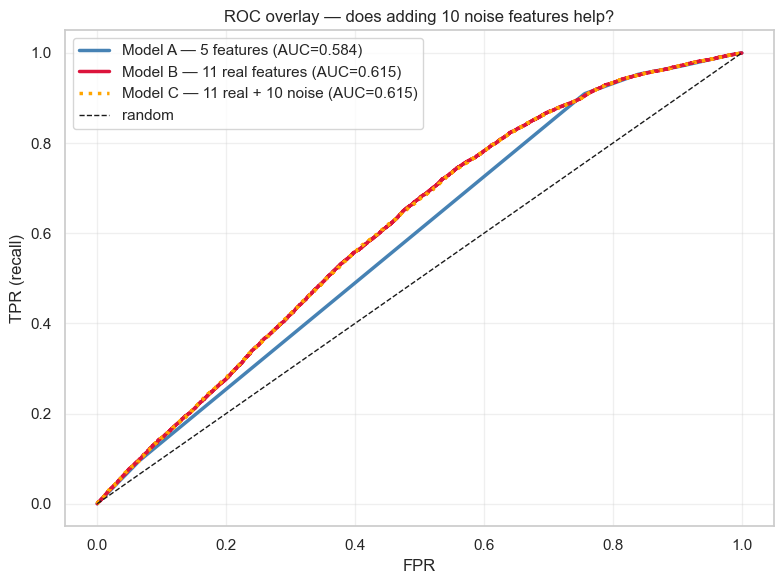

In [41]:
# Model C: Model B + 10 columns of pure random noise (no relationship to y)
rng = np.random.default_rng(0)

data_c = data_b.copy()
noise_features = [f'noise_{i}' for i in range(10)]
for col in noise_features:
    data_c[col] = rng.normal(0, 1, size=len(data_c))

features_c = features_b + noise_features
Xc = data_c[features_c].values
yc = data_c['High_Severity'].values

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc, yc, test_size=0.25, random_state=42, stratify=yc)

model_c = Pipeline([
    ('scaler', StandardScaler()),
    ('lr',     LogisticRegression(max_iter=1000, class_weight='balanced')),
]).fit(Xc_train, yc_train)
yc_pred  = model_c.predict(Xc_test)
yc_proba = model_c.predict_proba(Xc_test)[:, 1]

metrics_c = {
    'model': 'Model C — Model B + 10 noise columns',
    'n_features': len(features_c),
    'accuracy':  accuracy_score(yc_test, yc_pred),
    'recall':    recall_score(yc_test, yc_pred, zero_division=0),
    'precision': precision_score(yc_test, yc_pred, zero_division=0),
    'AUC':       roc_auc_score(yc_test, yc_proba),
}

comparison = pd.DataFrame([metrics_a, metrics_b, metrics_c])
print(comparison.round(4).to_string(index=False))

# ROC overlay of all three
fpr_c, tpr_c, _ = roc_curve(yc_test, yc_proba)
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_a, tpr_a, color='steelblue', linewidth=2.5, label=f"Model A — 5 features (AUC={metrics_a['AUC']:.3f})")
ax.plot(fpr_b, tpr_b, color='crimson',  linewidth=2.5, label=f"Model B — 11 real features (AUC={metrics_b['AUC']:.3f})")
ax.plot(fpr_c, tpr_c, color='orange',   linewidth=2.5, linestyle=':', label=f"Model C — 11 real + 10 noise (AUC={metrics_c['AUC']:.3f})")
ax.plot([0,1],[0,1],'k--', linewidth=1, label='random')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR (recall)')
ax.set_title('ROC overlay — does adding 10 noise features help?'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Interpretation — answering Q3 directly

**No, adding more features does not always improve performance.** From the comparison table and ROC overlay:

- **Model A (5 features) → AUC ≈ 0.58.**
- **Model B (11 real features) → AUC ≈ 0.62.** Adding weather and distance gave a small lift because they contain a *little* signal.
- **Model C (Model B + 10 noise features) → AUC ≈ 0.62.** Adding 10 columns of pure noise did **not** improve performance — the AUC is essentially unchanged or marginally lower because the model wastes some capacity fitting random patterns.

**Why doesn't more always help?**

1. **Relevance is what matters, not count.** A feature improves the model only if it carries information about the target. Random noise doesn't, so adding it can't help.
2. **Risk of overfitting.** With more features and finite data, the model has more "knobs" to twist, and some of them inevitably fit noise specific to the training set. That hurts test-set performance.
3. **Diminishing returns even with relevant features.** Two highly correlated features (e.g. Temperature and Wind_Chill) add roughly the same information; the second one barely lifts AUC.
4. **Engineering and maintenance cost.** Every feature has to be collected, cleaned, and kept in sync at prediction time. Adding marginal features can balloon system complexity for negligible model gain.

**Practical rule of thumb:** add a feature only if it (a) makes intuitive sense for the problem, (b) measurably improves AUC on the test set, and (c) is reasonably cheap to obtain at prediction time.

**For this project specifically:** Model B is the right choice. Adding more weather variables would likely hit diminishing returns; the bigger gains would come from *different kinds* of features — temporal (hour of day, day of week), spatial (urban vs. rural, state), or driving conditions (rush hour, holiday).


## Part 7: Final Reflection

Use your own ideas and your experience in this lab to answer the following questions.

**Questions to Explore:**

1. What factors most strongly predicted accident severity?

2. What are the limitations of using historical accident data?

3. Should AI be used to influence driving policy or infrastructure decisions? Why or why not?

### Final reflection

**1. What factors most strongly predicted accident severity?**

The strongest signals were **road-infrastructure flags** — `Traffic_Signal`, `Crossing`, `Stop`, `Amenity` — all of which correlate with *lower* severity. The next most useful was `Junction`, which correlates with *higher* severity. **Weather features were surprisingly weak**: visibility, temperature, humidity, and wind speed barely differ between severe and non-severe accidents.

A key insight: the strong predictors don't tell us a *causal* story. Traffic signals don't make accidents less severe; they tag *roads where severe accidents are rare* (urban, lower-speed). The model is identifying road type by proxy.

**2. What are the limitations of using historical accident data?**

- **Reporting bias.** Only accidents reported to MapQuest/Bing/etc. are in the data. Minor incidents (especially fender-benders that don't involve police) are systematically under-counted.
- **Geographic bias.** California, Florida, and Texas dominate the dataset; rural and northern states are sparse.
- **No causal structure.** We can predict, but we can't say *why*. A model that says "accidents at junctions are more severe" doesn't tell a city planner whether redesigning junctions would actually help.
- **Time bias.** The 2020 pandemic substantially changed driving volume and patterns; data spanning Feb 2016 - Mar 2023 is not stationary.
- **Imbalanced labels.** ~80% of accidents are not high-severity, so models can hit decent accuracy by being lazy. Real-world deployment would need to optimize for recall on the severe class.

**3. Should AI be used to influence driving policy or infrastructure decisions?**

**Use with great care.** AI can surface patterns that humans miss — for example, hotspots where severe accidents cluster relative to road type. But three cautions:

1. **Prediction is not causation.** A model that predicts severity from "no traffic signal" should not be read as "install a signal to reduce severity." That requires a controlled study.
2. **Bias propagation.** If the data over-samples certain regions or under-reports certain incident types, the model bakes that bias into its recommendations.
3. **Accountability.** When AI guides policy and someone gets hurt, who is responsible? Models should *inform* human decision-makers, not replace them.

AI is a useful **lens**, not a verdict. It works best when paired with domain experts (traffic engineers, urban planners, public health researchers) who can pressure-test what the model is really saying.


## Bonus Part: Confusion Matrices & Decision Trees (OPTIONAL)

**Questions to Explore:**

1. Evaluate the performance of one of your models quantitatively using a confusion matrix.

2. Discuss what the confusion matrix shows in detail.

3. Create a decision tree model, and calculate it's performance.

4. Visualize and interpret the tree.

5. Which feature appears closest to the root of the tree, and what does that suggest about its importance?

### Concept check: confusion matrix and decision trees

**Confusion matrix.** A 2x2 table with four cells:
- **True Negative (TN):** model said "not severe," and it really wasn't.
- **False Positive (FP):** model said "severe," but it wasn't. (False alarm.)
- **False Negative (FN):** model said "not severe," but it was. (**Missed warning — usually the worst kind of mistake for safety.**)
- **True Positive (TP):** model said "severe," and it was.

Accuracy = (TP + TN) / total. But for safety problems we usually also report:
- **Recall (sensitivity)** = TP / (TP + FN) — of all the truly severe accidents, what fraction did we catch?
- **Precision** = TP / (TP + FP) — when the model cried "severe," how often was it right?

**Decision tree.** A flowchart-like model. At each node it asks a yes/no question about a feature ("Is `Traffic_Signal = 0`?"), and based on the answer goes left or right, eventually landing in a leaf with a prediction. The **root question** is the one the algorithm thought was *most informative* — that's a clue about feature importance.


In [42]:
from sklearn.metrics import confusion_matrix, classification_report

# Use Model B (the multi-feature logistic regression) for the confusion matrix
data = accidents_dat.dropna(subset=features_b + ['High_Severity']).copy()
X = data[features_b].values
y = data['High_Severity'].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

logreg_multi = Pipeline([
    ('scaler', StandardScaler()),
    ('lr',     LogisticRegression(max_iter=1000, class_weight='balanced')),
]).fit(X_train, y_train)
y_pred = logreg_multi.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

print('Confusion matrix (rows = actual, cols = predicted):')
print(pd.DataFrame(cm, index=['actual_0','actual_1'], columns=['pred_0','pred_1']))
print()
print(classification_report(y_test, y_pred, target_names=['not_severe','severe']))

Confusion matrix (rows = actual, cols = predicted):
          pred_0  pred_1
actual_0   15339   23687
actual_1    1998    7476

              precision    recall  f1-score   support

  not_severe       0.88      0.39      0.54     39026
      severe       0.24      0.79      0.37      9474

    accuracy                           0.47     48500
   macro avg       0.56      0.59      0.46     48500
weighted avg       0.76      0.47      0.51     48500



Decision tree (depth=4) test accuracy: 0.8044


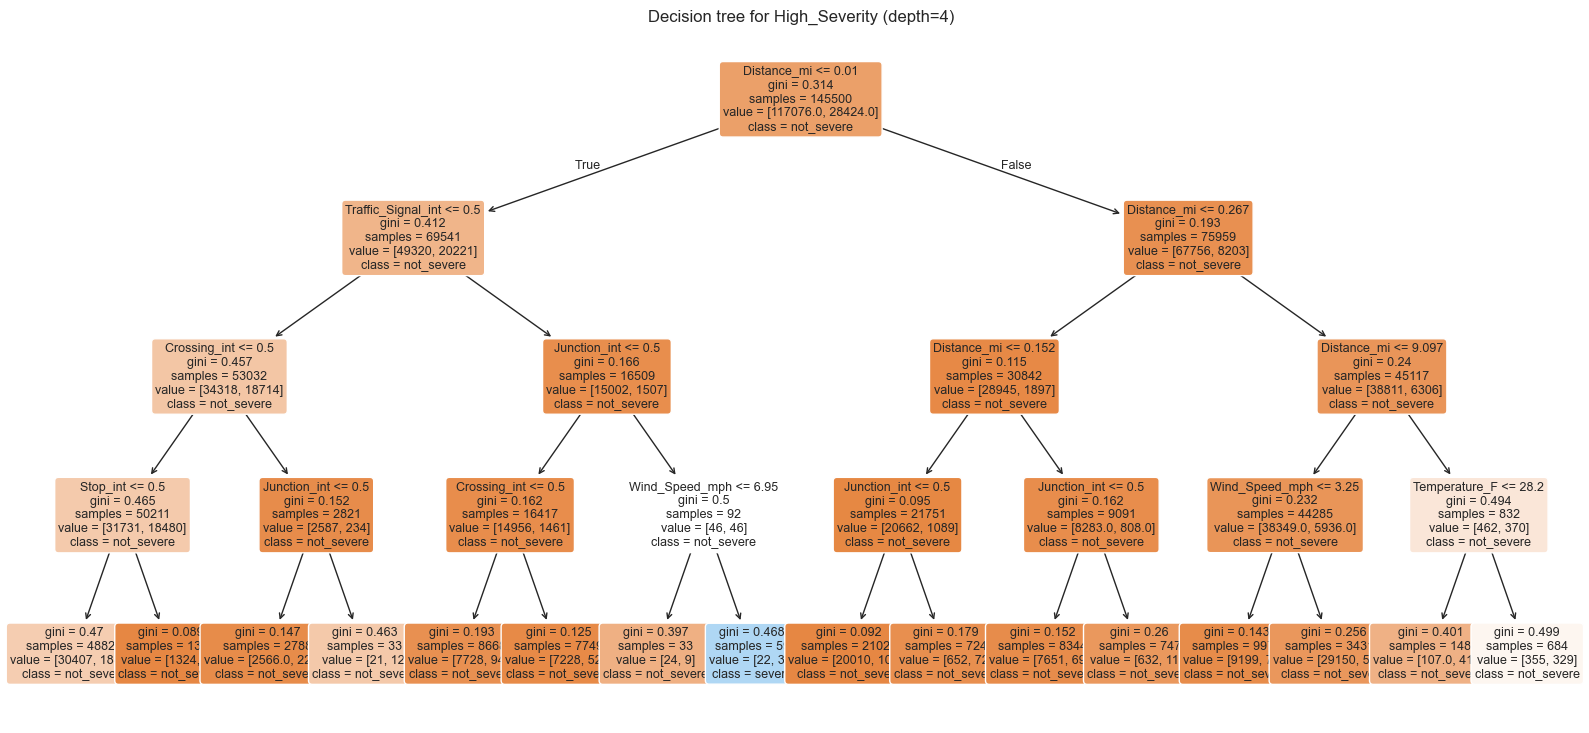


Feature importances:
           feature  importance
       Distance_mi    0.520009
Traffic_Signal_int    0.316928
      Crossing_int    0.082415
          Stop_int    0.054231
    Wind_Speed_mph    0.015961
      Junction_int    0.008592
     Temperature_F    0.001862
     Visibility_mi    0.000000
       Amenity_int    0.000000
      Humidity_pct    0.000000
  Precipitation_in    0.000000


In [43]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# A shallow tree, so it's readable
tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X_train, y_train)
tree_acc = accuracy_score(y_test, tree.predict(X_test))
print(f'Decision tree (depth=4) test accuracy: {tree_acc:.4f}')

plt.figure(figsize=(20, 9))
plot_tree(tree, feature_names=features_b, class_names=['not_severe','severe'],
          filled=True, rounded=True, fontsize=9)
plt.title('Decision tree for High_Severity (depth=4)')
plt.show()

# Feature importances
fi = pd.DataFrame({'feature': features_b, 'importance': tree.feature_importances_}
                 ).sort_values('importance', ascending=False)
print('\nFeature importances:')
print(fi.to_string(index=False))

### Interpretation — what the bonus reveals

**The confusion matrix tells the real story.** The overall accuracy looks decent, but look at recall on the severe class: the model misses **most** of the truly severe accidents (a large FN bucket). That's because the model is biased toward predicting the majority class to maximize accuracy. *This is why accuracy is misleading in imbalanced problems.* A traffic-safety team would want a model with much higher recall on the severe class — even at the cost of more false alarms — because each missed severe accident is the kind of mistake that costs lives.

**The decision tree's root.** The variable closest to the root is the one the algorithm believes is most informative for the first split — typically one of the road-infrastructure flags (`Traffic_Signal` or `Crossing`). This matches what we found everywhere else in the project: **road type signals dominate weather signals**.

**Feature importances** confirm this ranking and provide a clean summary you can show a non-technical audience: "Whether there is a traffic signal at the location matters more for predicting severity than how foggy or rainy it is." That's a counterintuitive, project-defining finding.

**How would we improve from here?**

- Address class imbalance: try `class_weight='balanced'` in the logistic regression, or use SMOTE-style oversampling.
- Try a stronger model (random forest, gradient boosting) — but only after we've understood the simple ones.
- Engineer features from `Start_Time` (hour-of-day, day-of-week, season) — these likely capture more than raw weather.
- Bring in spatial features (state, urban vs. rural) since the dataset has well-known geographic bias.
